In [1]:
#conda install -c conda-forge selenium

In [2]:
 #conda install conda-forge::webdriver-manager 

In [3]:
#conda install -c conda-forge Pillow

In [4]:
import tkinter as tk
from tkinter import ttk, messagebox, filedialog
import requests # Usaremos requests en lugar de selenium para la lista inicial
from bs4 import BeautifulSoup
import threading
import time
import re
import base64 
import datetime 
import json 
from PIL import Image, ImageTk
import io # To handle image data in memory
from urllib.parse import urljoin
from io import BytesIO  # Para manejar bytes de imagen como archivo
from PIL import Image, ImageTk # Para procesar y mostrar la imagen
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.patches import Polygon
from matplotlib.offsetbox import AnnotationBbox, TextArea, HPacker, VPacker
from PIL import Image
import csv
import numpy as np




In [5]:
### UTILS.PY

def get_coordinates(n):
    """
    Function for getting coordinates and rotation values for the labels.

    Args:
        n (int): number of labels.

    Returns:
        list: coordinate and rotation values.
    """    

    ## calculate alpha
    alpha = 2 * np.pi/n

    ## rotation values
    alphas = alpha * np.arange(n)

    ## x-coordinate value
    coord_x = np.cos(alphas)

    ## y-coordinate value
    coord_y = np.sin(alphas)

    return np.c_[coord_x, coord_y, alphas]

def get_vertex_coord(old_value, old_min, old_max, new_min, new_max):
    """
    Function for getting coordinate for each vertex of the polygon.

    Args:
        old_value, old_min, old_max, new_min, new_max -- float values.

    Returns:
        float: the coordinate value either x or y.
    """    

    ## calculate the value
    new_value = ( (old_value - old_min) / (old_max - old_min) ) * (new_max - new_min) + new_min

    return new_value

def get_indices_between(range_list, coord_list, value, reverse):
    """
    Function to get the x-coordinate and y-coordinate for the polygon vertex.

    Args:
        range_list (list): range value for a particular parameter.
        coord_list (list): coordinate values where the numerical labels are placed.
        value (float): the value of the parameter.
        reverse (bool): to tell whether the range values are in reversed order or not.

    Returns:
        tuple: x-coordinate and y-coordinate value.
    """    

    ## getting index value
    idx_1, idx_2 = get_index(array=range_list, value=value, reverse=reverse)

    ## get x coordinate
    x_coord = get_vertex_coord(
        old_value=value,
        old_min=range_list[idx_1],
        old_max=range_list[idx_2],
        new_min=coord_list[idx_1, 0],
        new_max=coord_list[idx_2, 0]
    )

    ## get y coordinate
    y_coord = get_vertex_coord(
        old_value=value,
        old_min=range_list[idx_1],
        old_max=range_list[idx_2],
        new_min=coord_list[idx_1, 1],
        new_max=coord_list[idx_2, 1]
    )

    return x_coord, y_coord

def get_index(array, value, reverse):
    """
    Function to get the indices of two list items between which the value lies.

    Args:
        array (list): containing numerical values.
        value (float/int): value to be searched.
        reverse (bool): whether or not the range values are in reverse order.

    Returns:
        int: the two indices between which value lies.
    """    

    if reverse == True:
        ## loop over the array/list
        for i in range(0, len(array) - 1):
            if array[i] >= value >= array[i+1]:
                return i, i+1

    ## loop over the array/list
    for i in range(0, len(array) - 1):
        if array[i] <= value <= array[i+1]:
            return i, i+1

def set_labels(ax, label_value, label_axis):
    """
    Function to set label for a given axis.

    Args:
        ax (axes.Axes): axis object.
        label_value (list): ticklabel values.
        label_axis (str): axis name, 'x' or 'y'

    Returns:
        list: label names
    """    

    if label_axis == 'x':
        ax.set_xticks(np.arange(len(label_value)))
        axis = ax.get_xticklabels()
    else:
        ax.set_yticks(np.arange(len(label_value)) + 1)
        axis = ax.get_yticklabels()
    
    ## fetch labels
    labels = [items.get_text() for items in axis]

    ## init a count variable
    if label_axis == 'x':
        count = 0
    else:
        count = len(label_value) - 1
    
    ## iterate through all the labels and change the label name
    for i in range(len(labels)):
        labels[i] = label_value[count]

        if label_axis == 'x':
            count += 1
        else:
            count -= 1
    
    return labels            

def add_image(image, fig, left, bottom, width=None, height=None, **kwargs):
    """
    -----> The method is taken from mplsoccer package (from github) <-----
    -----> Andy Rowlinson(@numberstorm) <-----

    Adds an image to a figure using fig.add_axes and ax.imshow

    Args:
        image (str): image path.
        fig (matplotlib.figure.Figure): figure object
        left (float): The left dimension of the new axes.
        bottom (float): The bottom dimension of the new axes.
        width (float, optional): The width of the new axes. Defaults to None.
        height (float, optional): The height of the new axes. Defaults to None.
        **kwargs: All other keyword arguments are passed on to matplotlib.axes.Axes.imshow.

    Returns:
        matplotlib.figure.Figure: figure object.
    """    
    ## open image
    image = Image.open(image)

    ## height, width, channel of shape
    shape = np.array(image).shape
    
    image_height, image_width =  shape[0], shape[1]
    image_aspect = image_width / image_height
    
    figsize = fig.get_size_inches()
    fig_aspect = figsize[0] / figsize[1]
    
    if height is None:
        height = width / image_aspect * fig_aspect
    
    if width is None:
        width = height*image_aspect/fig_aspect
    
    ## add image
    ax_image = fig.add_axes((left, bottom, width, height))
    ax_image.axis('off')  # axis off so no labels/ ticks
    
    ax_image.imshow(image, **kwargs)
    
    return fig

def plot_text(x, y, text, text_dict, ax, color_rest='k', align="left", fontsize=None, **kwargs):
    """
    Function to plot text.

    Args:
        x (float): x-coodrinate value for text.
        y (float): y-coodrinate value for text.
        text (str): the text that will be plotted.
        text_dict (dict): contains words that the user wants to format.
        ax (axes.Axes): axis object.
        color_rest (str, optional): color for the string. Defaults to 'k'.
        align (str, optional): alignment, can have these values {'top', 'bottom', 'left', 'right', 'center', 'baseline'}. Defaults to "left". 
        fontsize (float, optional): size of the font. Defaults to None.
        **kwargs(optional): All other keyword arguments are passed on to matplotlib.axes.Axes.imshow.

    Returns:
        axes.Axes: axis object
    """    

    ## init an empty list and a count variable to 0
    hpacker_list = []
    count = 0
    
    for sentence in text.split('\n'):
        ## init an empty string and list
        temp_string = ""
        temp_hpacker = []
        
        for word in sentence.split(' '):
            present = text_dict.get(word)
            
            if present == None:
                temp_string += (word + " ")
                
            elif present and temp_string != "":
                if type(fontsize) == list:
                    size = fontsize[count]
                else:
                    size = fontsize

                textbox = TextArea(
                    temp_string.strip(),
                    textprops = dict(
                        color = color_rest,  
                        size = size,
                        **kwargs
                    )
                )
                temp_hpacker.append(textbox)
                temp_string = ""
            
            if present:
                if present.get("color") == None:
                    color = color_rest
                else:
                    try:
                        color = present["color"]
                    except Exception:
                        color = present["fontcolor"]

                if present.get("ignore") == True:
                    word = word.replace('_', ' ')
                    del present["ignore"]

                if present.get("size") or present.get("fontsize"):
                    try:
                        size = present["fontsize"]
                    except Exception:
                        size = present["size"]
                elif type(fontsize) == list:
                    size = fontsize[count]
                else:
                    size = fontsize

                if present.get("ignore_last") == True:
                    w_1 = word[:-1]
                    w_2 = word[-1]
                    del present["ignore_last"]

                    textbox_1 = TextArea(
                        w_1,
                        textprops = dict(      
                            present,
                            color = color,
                            size = size,
                            **kwargs
                        )
                    )

                    textbox_2 = TextArea(
                        w_2,
                        textprops = dict(      
                            present,
                            color = color_rest,
                            size = size,
                            **kwargs
                        )
                    )    

                    temp_box = HPacker(children=[textbox_1, textbox_2], align=align, pad=0, sep=0)
                    temp_hpacker.append(temp_box)

                else:
                    textbox = TextArea(
                        word,
                        textprops = dict(      
                            present,
                            color = color,
                            size = size,
                            **kwargs
                        )
                    )
                    temp_hpacker.append(textbox)
        
        if len(temp_string) > 0:
            if type(fontsize) == list:
                size = fontsize[count]
            else:
                size = fontsize

            textbox = TextArea(
                temp_string.strip(),
                textprops = dict(
                    color = color_rest,    
                    size = size,
                    **kwargs
                )
            )
            temp_hpacker.append(textbox)
        
        count += 1
        box_h = HPacker(children=temp_hpacker, align=align, pad=0, sep=4)
        hpacker_list.append(box_h)
        
    final_box = VPacker(children=hpacker_list, pad=0, sep=4)

    text = AnnotationBbox(final_box, (x, y), frameon=False)
    ax.add_artist(text)
    
    return ax    

In [6]:
class Radar:
    """
    class contains methods to make radar-chart.
    """

    def __init__(
        self, background_color="#FFFFFF", patch_color="#D6D6D6", fontfamily="Times New Roman", 
        label_fontsize=10, range_fontsize=6.5, label_color="#000000", range_color="#000000"
        ):
        """
        Function to initialize the object of the class.

        Args:
            background_color (str, optional): the background color. Defaults to "#FFFFFF".
            patch_color (str, optional): the color for our circle. Defaults to "#D6D6D6".
            fontfamily (str, optional): fontfamily available in matplotlib. Defaults to "Times New Roman".
            label_fontsize (float, optional): the fontsize of label. Defaults to 10.
            range_fontsize (float, optional): the fontsize for range values. Defaults to 6.5.
            label_color (str, optional): color value for labels. Defaults to "#000000".
            range_color (str, optional): color value for ranges. Defaults to "#000000".
        """        
        self.background_color = background_color
        self.patch_color = patch_color
        self.fontfamily = fontfamily
        self.label_fontsize = label_fontsize
        self.range_fontsize = range_fontsize
        self.label_color = label_color
        self.range_color = range_color

    def plot_radar(self, ranges, params, values, radar_color, filename=None, dpi=300,
                   title=dict(), alphas=[0.6, 0.6], compare=False, endnote=None, 
                   end_size=9, end_color="#95919B", image=None, image_coord=None, figax=None, **kwargs):
        """
        Function to plot radar-chart.

        Args:
            ranges (list): list of tuples containing min and max value for each parameter.
            params (list): list of string values containing the name of parameters.
            values (list): list of float values for each parameters/ nested list when making comparison charts.
            radar_color (list): list of two color values.
            filename (str, optional): the name per which the file will be saved added extension. Defaults to None.
            dpi (int, optional): dots per inch value. Defaults to 300.
            title (str, optional): containing information of title and subtitle. Defaults to dict().
            alphas (list, optional): alpha value for color. Defaults to [0.6, 0.6].
            compare (bool, optional): True, if comparison charts are to be made. Defaults to False.
            endnote (str, optional): the endnote of the plot. Defaults to None.
            end_size (int, optional): the font-size for the endnote string. Defaults to 9.
            end_color (str, optional): color of the endnote. Defaults to "#95919B".
            image (str, optional): image name to be added. Defaults to None.
            image_coord (list, optional): containing left, bottom, width, height for image. Defaults to None.
            figax tuple, optional): figure and axis object. Defaults to None.
            **kwargs --  All other keyword arguments are passed on to matplotlib.axes.Axes.imshow.

        Returns:
            matplotlib.figure.Figure: figure object.
            axes.Axes: axis object.
        """        
        
        ## assert required conditions 
        assert len(ranges) >= 3, "Length of ranges should be greater than equal to 3"
        assert len(params) >= 3, "Length of params should be greater than equal to 3"

        if compare == True:
            ## for making comparison radar charts
            assert len(values) == len(radar_color) == len(alphas), "Length for values, radar_color and alpha do not match"
        else:
            assert len(values) >= 3, "Length of values should be greater than equal to 3"
            assert len(ranges) == len(params) == len(values), "Length for ranges, params and values not matched"

        if figax:
            fig, ax = figax
        else:
            fig, ax = plt.subplots(figsize=(20, 10), facecolor=self.background_color)
            ax.set_facecolor(self.background_color)

        ## set axis
        ax.set_aspect('equal')
        ax.set(xlim=(-22, 22), ylim=(-23, 25))

        if type(radar_color) == str:
            ## make radar_color a list
            radar_color = [radar_color]
            radar_color.append('#D6D6D6')

        ## add labels around the last circles
        ax = self.__add_labels(params=params, ax=ax)

        ## add ranges
        ax, xy, range_values = self.__add_ranges(ranges=ranges, ax=ax,)

        if compare == True:
            ## for making comparison radar charts

            for i in range(len(values)):
                ## fetch value
                value = values[i]

                ## get vertices
                vertices = self.__get_vertices(value, xy, range_values)

                ## make the radar chart
                ax = self.__plot_circles(ax=ax, radar_color=radar_color[i], vertices=vertices, alpha=alphas[i], compare=True)

        else:
            ## get vertices
            vertices = self.__get_vertices(values, xy, range_values)

            ## make the radar chart
            ax = self.__plot_circles(ax=ax, radar_color=radar_color, vertices=vertices)
        
        ## add credits 
       # ax.text(22, -21.5, 'Inspired By: Statsbomb / Rami Moghadam', fontfamily=self.fontfamily, ha='right',
        #        fontdict={"color": end_color}, fontsize=end_size)

        ## add endnote
        if endnote != None:
            y_add = -22.5
            for note in endnote.split('\n'):
                ax.text(22, y_add, note, fontfamily=self.fontfamily, ha='right',
                        fontdict={"color": end_color}, fontsize=end_size)
                y_add -= 1

        ## tidy axis
        ax.axis('off')
        
        if len(title) > 0:
            ax = self.__plot_titles(ax, title)

        ## add image
        if image != None and image_coord != None:
            fig = add_image(image, fig, image_coord[0], image_coord[1], image_coord[2], image_coord[3], **kwargs)

        if filename:
            fig.savefig(filename, dpi=dpi, bbox_inches='tight')

        return fig, ax

    def __plot_titles(self, ax, title):
        """
        Function for plotting title values to the radar-chart.

        Args:
            ax (axes.Axes): axis object.
            title (dict): containing information of title and subtitle.

        Returns:
            axes.Axes: axis object.
        """        

        if title.get('title_color') == None:
            ## add title color
            title['title_color'] = '#000000'

        if title.get('subtitle_color') == None:
            ## add a subtitle color
            title['subtitle_color'] = '#000000'

        if title.get('title_fontsize') == None:
            ## add titile fontsize
            title['title_fontsize'] = 20
        
        if title.get('sub_title_fontsize') == None:
            ## add subtitle fontsize
            title['subtitle_fontsize'] = 15

        if title.get('title_fontsize_2') == None:
            ## add title fontsize 2
            title['title_fontsize_2'] = title['title_fontsize']

        if title.get('subtitle_fontsize_2') == None:
            ## add subtitle fontsize 2
            title['subtitle_fontsize_2'] = title['subtitle_fontsize']   

        if title.get('title_name'):
            ## plot the title name
            ax.text(-22, 24, title['title_name'], fontsize=title['title_fontsize'], fontweight='bold', 
                    fontdict={'color': title['title_color']}, fontfamily=self.fontfamily)
        
        if title.get('subtitle_name'):
            ## plot the title name
            ax.text(-22, 22, title['subtitle_name'], fontsize=title['subtitle_fontsize'], 
                    fontdict={'color': title['subtitle_color']}, fontfamily=self.fontfamily)

        if title.get('title_color_2') == None:
            ## add title color
            title['title_color_2'] = '#000000'
        
        if title.get('subtitle_color_2') == None:
            ## add subtitle color
            title['subtitle_color_2'] = '#000000'
        
        if title.get('title_name_2'):
            ## plot the second title name
            ax.text(22, 24, title['title_name_2'], fontsize=title['title_fontsize_2'], fontweight='bold', 
                    fontdict={'color': title['title_color_2']}, ha='right', fontfamily=self.fontfamily)
        
        if title.get('subtitle_name_2'):
            ## plot the second subtitle name
            ax.text(22, 22, title['subtitle_name_2'], fontsize=title['subtitle_fontsize_2'], 
                    fontdict={'color': title['subtitle_color_2']}, ha='right', fontfamily=self.fontfamily) 
        
        return ax

    def __plot_circles(self, ax, radar_color, vertices, alpha=None, compare=False):
        """
        Function to plot concentric circles.

        Args:
            ax (axes.Axes): axis object.
            radar_color (list): color values.
            vertices (list): coordinate values for each vertex of the polygon.
            alpha (list, optional): alpha values for colors. Defaults to None.
            compare (bool, optional): True, if a comparison chart is to be made. Defaults to False.

        Returns:
            axes.Axes: axis object.
        """        

        ## radius value for each circle
        radius = [3.35, 6.7, 10.05, 13.4, 16.75]

        ## linewidth, zorder for circle
        lw_circle, zorder_circle =  20, 2

        if compare:    ## for making comparison radar charts
            ## plot a polygon
            radar_1 = Polygon(vertices, fc=radar_color, zorder=zorder_circle+1, alpha=alpha)
            ax.add_patch(radar_1)
        else:
            ## plot a polygon
            radar_1 =  Polygon(vertices, fc=radar_color[0], zorder=zorder_circle-1)
            ax.add_patch(radar_1)

        ## create concentric circles 
        for rad in radius:
            ## create circle
            circle_1 = plt.Circle(xy=(0, 0), radius=rad, fc='none', ec=self.patch_color, lw=lw_circle, zorder=zorder_circle)
            ax.add_patch(circle_1)

            if compare == False:
                ## create another circle to fill in second color
                circle_2 = plt.Circle(xy=(0, 0), radius=rad, fc='none', ec=radar_color[1], lw=lw_circle, zorder=zorder_circle+1)
                circle_2.set_clip_path(radar_1)
                ax.add_patch(circle_2)
        
        return ax

    def __add_labels(self, params, ax, return_list=False, radius=19, range_val=False):
        """
        Function to add labels around the last circle.

        Args:
            params (list): values containing the name of parameters.
            ax (axes.Axes): axis object.
            return_list (bool, optional): x and y values. Defaults to False.
            radius (int, optional): radius of the circle around which labels are to be align. Defaults to 19.
            range_val (bool, optional): to specify whether to plot range or not. Defaults to False.

        Returns:
            axes.Axes: axis object.
            list: coordinate values (if return_list == True)
        """        
        
        ## get coordinates and rotation values
        coord = get_coordinates(n=len(params))

        if return_list == True:
            x_y = []

        for i in range(len(params)):
            ## fetch rotation value
            rot = coord[i, 2]

            ## the x and y coordinate for labels
            x, y = (radius*np.sin(rot), radius*np.cos(rot))

            if return_list == True:
                ## add x_y cordinates 
                tup_temp = (x, y)
                x_y.append(tup_temp)

            if y < 0:
                rot += np.pi

            if type(params[i]) == np.float64:
                p = round(params[i], 2)
            else:
                p = params[i]

            if range_val == True:
                size = self.range_fontsize
                color = self.range_color
            else:
                size = self.label_fontsize
                color = self.label_color
        
            ax.text(x, y, p, rotation=-np.rad2deg(rot), ha='center', va='center', 
                    fontsize=size, fontfamily=self.fontfamily, fontdict=dict(color=color))
        
        if return_list == True:
            return ax, x_y
        else:
            return ax

    def __add_ranges(self, ranges, ax):
        """
        Function to add range value around each circle.

        Args:
            ranges (list): list of tuples containing min and max value for each parameter.
            ax (axes.Axes): axis object.

        Returns:
            axes.Axes: axis object.
            numpy.array: x and y coordinate for each numerical range values.
            numpy.array: range value for each parameter.
        """        

        ## radius value for every circle
        radius = [2.5, 4.1, 5.8, 7.5, 9.2, 10.9, 12.6, 14.3, 15.9, 17.6]

        ## x and y coordinate values for range numbers
        x_y = []

        ## range values for every ranges
        range_values = np.array([])

        for rng in ranges:
            value = np.linspace(start=rng[0], stop=rng[1], num=10)
            range_values = np.append(range_values, value)
        
        range_values = range_values.reshape((len(ranges),10))

        for i in range(len(radius)):

            ## parameter list
            params = range_values[:, i]

            ax, xy = self.__add_labels(params=params, ax=ax, return_list=True, radius=radius[i], range_val=True)
            x_y.append(xy)

        return ax, np.array(x_y), range_values

    def __get_vertices(self, values, xy, range_values):
        """
        Function to get vertex coordinates(x and y) for the required polygon.

        Args:
            values (list): value for each parameter.
            xy (numpy.array): coordinate values for each label-number.
            range_values (numpy.array): range value for each parameter.

        Returns:
            numpy.array: coordinates for each vertex of the polygon.
        """        

        ## init an empty list
        vertices = []

        ## calculating coordinate values
        for i in range(len(range_values)):
            
            ## list of range value for each parameter
            range_list = range_values[i, :]
            coord_list = xy[:, i]

            if range_list[0] > range_list[-1]:
                ## if range values are in reversed order
                if values[i] >= range_list[0]:
                    ## if value is greater
                    x_coord, y_coord = coord_list[0, 0], coord_list[0, 1]

                elif values[i] <= range_list[-1]:
                    ## if value is smaller
                    x_coord, y_coord = coord_list[-1, 0], coord_list[-1, 1]

                else:
                    ## get indices between which the value is present
                    x_coord, y_coord = get_indices_between(range_list=range_list, coord_list=coord_list, value=values[i], reverse=True)

            else:
                if values[i] >= range_list[-1]:
                    ## if value is greater
                    x_coord, y_coord = coord_list[-1, 0], coord_list[-1, 1]

                elif values[i] <= range_list[0]:
                    ## if value is smaller
                    x_coord, y_coord = coord_list[0, 0], coord_list[0, 1]

                else:
                    ## get indices between which the value is present
                    x_coord, y_coord = get_indices_between(range_list=range_list, coord_list=coord_list, value=values[i], reverse=False)

            ## add x-y coordinate in vertices as a list
            vertices.append([x_coord, y_coord])
        
        return vertices       

    def __repr__(self):
        return f"""{self.__class__.__name__}(
            background_color={self.background_color},
            patch_color={self.patch_color},
            fontfamily={self.fontfamily},
            label_fontsize={self.label_fontsize},
            range_fontsize={self.range_fontsize},
            label_color={self.label_color},
            range_color={self.range_color}
        )"""

    ## __str__ is the same as __repr__
    __str__ = __repr__

In [7]:
class Tooltip:
    """
    Crea un cuadro de texto emergente (tooltip) para un widget de tkinter.
    """
    def __init__(self):
        self.waittime = 500     # Milisegundos para esperar antes de mostrar
        self.wraplength = 250   # Píxeles antes de que el texto se divida en una nueva línea
        self.widget = None
        self.text = None
        self.id = None
        self.tw = None

    def show(self, widget, text, event):
        """Muestra el tooltip después de un breve retardo."""
        self.widget = widget
        self.text = text
        # Cancela cualquier evento de mostrar tooltip programado anteriormente
        if self.id:
            self.widget.after_cancel(self.id)
        # Programa la aparición del tooltip
        self.id = self.widget.after(self.waittime, lambda: self._show_tip(event))

    def hide(self):
        """Oculta el tooltip."""
        if self.id:
            self.widget.after_cancel(self.id)
            self.id = None
        if self.tw:
            self.tw.destroy()
            self.tw = None

    def _show_tip(self, event):
        """Crea y posiciona la ventana del tooltip."""
        # Si ya hay un tooltip, lo destruye
        if self.tw:
            self.tw.destroy()
        
        # Usa las coordenadas del evento para posicionar el tooltip cerca del cursor
        x = event.x_root + 20
        y = event.y_root + 10
        
        self.tw = tk.Toplevel(self.widget)
        self.tw.wm_overrideredirect(True) # Sin bordes de ventana
        self.tw.wm_geometry(f"+{x}+{y}")

        label = ttk.Label(self.tw, text=self.text, justify=tk.LEFT,
                          background="#FFFFE0", relief=tk.SOLID, borderwidth=1,
                          wraplength=self.wraplength, padding=(5, 3))
        label.pack(ipadx=1)


DEBUG: Iniciando create_gui...
DEBUG: ttkthemes no encontrado. Intentando crear tk.Tk...
DEBUG: tk.Tk creado: app = .
DEBUG: Antes de configurar título/geometría, app = .
Cargando lista de clubes vía AJAX...
DEBUG: Iniciando app.mainloop()
Obteniendo lista completa de clubes vía AJAX...
DEBUG: Accediendo a https://www.basquetcatala.cat/clubs/ajax
DEBUG: Petición AJAX exitosa (Status: 200). Procesando JSON...
DEBUG: JSON decodificado. Tipo: <class 'list'>
DEBUG: Se recibieron 425 elementos en la lista JSON.
Proceso completado. Total clubes encontrados: 425
DEBUG: Extracción finalizada. 425 clubes mapeados.
Lista de clubes cargada. Seleccione un club.
Obteniendo equipos para CLUB DE BASQUET INSTITUCIO MONTSERRAT (BIM)...
Obteniendo equipos para club ID: 45...
DEBUG [fetch_teams]: Encontrados 6 divs 'table-responsive'.
DEBUG [fetch_teams]: Enlace equipo encontrado: 'BIM', URL: '/equip/73595'
DEBUG [fetch_teams]:  -> Competición encontrada: 'C.T. SOTS-25 MASCULÍ NIVELL B						|'
DEBUG [fet

2025-07-01 01:33:05.802 python[27870:2563693] The class 'NSSavePanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


Datos de jugadores (Overall) guardados en: /Users/ignaciodelgadodelvalle/Downloads/UNIO_BASQUET_SANT_ADRIA_C.C._JÚNIOR_MASCULÍ_INTERTERRITORIAL_-_UB_SANT_ADRIA_1_overall_jugadores.csv


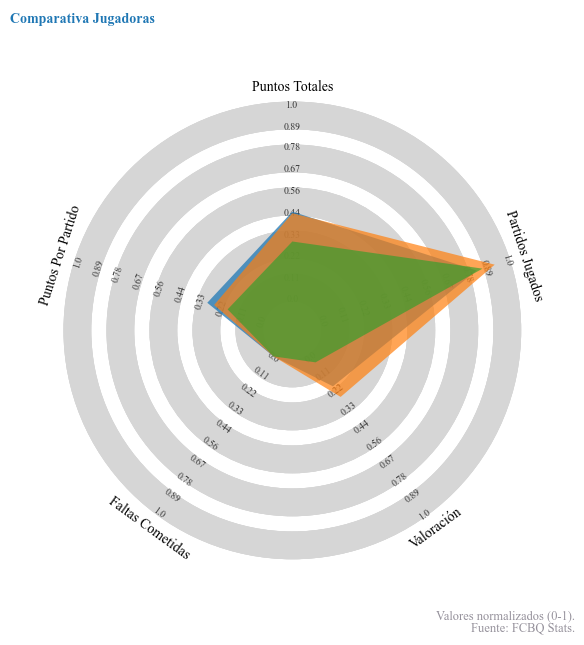

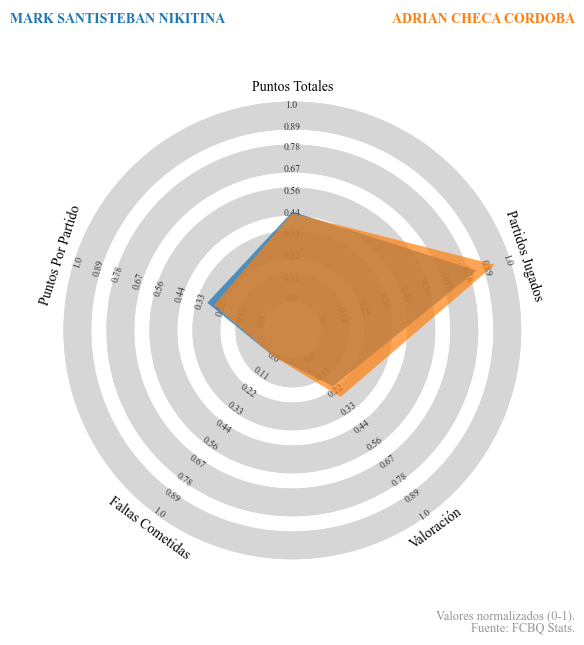

In [8]:
# --- Configuración  ---
AJAX_CLUBS_URL = "https://www.basquetcatala.cat/clubs/ajax"
URL_CLUB_BASE = "https://www.basquetcatala.cat/club/{}"
URL_TEAM_PAGE_BASE = "https://www.basquetcatala.cat{}" # Para construir URL completa del equipo
# Definimos la plantilla de la URL de la API (mejor fuera de la función)
API_STATS_URL_TEMPLATE = "https://msstats.optimalwayconsulting.com/v1/fcbq/team-stats/team/{}/season/{}"

# --- Constantes  ---
AJAX_CLUBS_URL = "https://www.basquetcatala.cat/clubs/ajax"
URL_CLUB_BASE = "https://www.basquetcatala.cat/club/{}"
URL_TEAM_PAGE_BASE = "https://www.basquetcatala.cat{}"
REQUEST_HEADERS = {
    'User-Agent': 'Mozilla/5.0 ...', # Tu User-Agent completo
    'Accept': 'application/json, text/javascript, */*; q=0.01',
    'X-Requested-With': 'XMLHttpRequest',
    'Accept-Language': 'es-ES,es;q=0.9,ca;q=0.8,en;q=0.7'
}
# -- Constantes API Logo --
LOGO_API_KEY_PART = "jR4rgA5K6Chhh5vyfrxo9wTScdg2NT7K"
LOGO_URL_TEMPLATE = "https://esb.optimalwayconsulting.com/fcbq/1/{}/Clubs/getImageByTeamId/{}"

#--- Colores y alphas para la comparación de múltiples jugadores ---
PLAYER_COMPARISON_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
PLAYER_COMPARISON_ALPHAS = [0.75, 0.7, 0.65, 0.6, 0.55, 0.5] # Alphas correspondientes
MAX_PLAYERS_TO_COMPARE = len(PLAYER_COMPARISON_COLORS)

RADAR_CLASS_AVAILABLE = True

# --- >> Constantes API Estadísticas << ---
API_STATS_URL_TEMPLATE_OVERALL = "https://msstats.optimalwayconsulting.com/v1/fcbq/team-stats/team/{}/season/{}"
API_STATS_URL_TEMPLATE_HOME    = "https://msstats.optimalwayconsulting.com/v1/fcbq/team-stats/team/{}/season/{}/playas/lo"
API_STATS_URL_TEMPLATE_AWAY    = "https://msstats.optimalwayconsulting.com/v1/fcbq/team-stats/team/{}/season/{}/playas/vs"


# --- Constantes API Logo ---
LOGO_API_KEY_PART = "jR4rgA5K6Chhh5vyfrxo9wTScdg2NT7K" 
LOGO_URL_TEMPLATE = "https://esb.optimalwayconsulting.com/fcbq/1/{}/Clubs/getImageByTeamId/{}"

REQUEST_HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36',
    'Accept': 'application/json, text/javascript, */*; q=0.01',
    'X-Requested-With': 'XMLHttpRequest',
    # Añadir Accept-Language puede ayudar a veces
    'Accept-Language': 'es-ES,es;q=0.9,ca;q=0.8,en;q=0.7'
}

# --- Variables Globales ---
club_data = {}      # {nombre_club: id_club}
teams_data = {}     # {display_text: team_page_relative_url} <- ¡NUEVO!
app = None
status_label = None
club_combo = None
team_combo = None
stats_display = None # <- Widget para mostrar estadísticas
logo_label = None
widgets_by_tab = {}  
matplot_figures = {} 
scopes_data_for_radar = {} 

RADAR_PARAMS_DISPLAY = [
    "Puntos Totales",
    "Partidos Jugados",
    "Valoración",
    "Faltas Cometidas", 
    "Puntos Por Partido"
]

STAT_CONFIG_FOR_RADAR = {
    "Puntos Totales":       {'key': 'totalScore',       'max': 500,  'invert': False}, # Ajusta 'max' 
    "Partidos Jugados":     {'key': 'matchesPlayed',    'max': 30,   'invert': False},
    "Valoración":           {'key': 'sumValoration',    'max': 600,  'invert': False},
    "Faltas Cometidas":     {'key': 'sumFouls',         'max': 10,  'invert': True}, # Menos faltas es mejor
    "Puntos Por Partido":   {'key': 'calculated_ppp',   'max': 30,   'invert': False} 
    
}


# --- get_all_clubs_ajax  ---
def get_all_clubs_ajax(progress_callback):
    """Obtiene TODOS los clubes directamente desde la URL AJAX."""
    progress_callback("Obteniendo lista completa de clubes vía AJAX...")
    print(f"DEBUG: Accediendo a {AJAX_CLUBS_URL}")
    extracted_clubs = {}
    try:
        response = requests.get(AJAX_CLUBS_URL, headers=REQUEST_HEADERS, timeout=20)
        response.raise_for_status()
        print(f"DEBUG: Petición AJAX exitosa (Status: {response.status_code}). Procesando JSON...")
        try:
            data = response.json()
            print(f"DEBUG: JSON decodificado. Tipo: {type(data)}")
            if isinstance(data, list):
                print(f"DEBUG: Se recibieron {len(data)} elementos en la lista JSON.")
                for club_obj in data:
                    club_id = club_obj.get('id')
                    club_name = club_obj.get('name')
                    if club_id is not None and club_name:
                        club_name_clean = club_name.strip()
                        if club_name_clean:
                            extracted_clubs[club_name_clean] = str(club_id)
                    # else: print(f"WARN: Objeto club en JSON sin 'id' o 'name': {club_obj}") # Optional log
                progress_callback(f"Proceso completado. Total clubes encontrados: {len(extracted_clubs)}")
                print(f"DEBUG: Extracción finalizada. {len(extracted_clubs)} clubes mapeados.")
                return extracted_clubs
            else:
                print(f"ERROR: La respuesta JSON no es una lista, es tipo {type(data)}.")
                progress_callback("Error: Formato de respuesta inesperado del servidor.")
                return {}
        except json.JSONDecodeError as json_err:
            print(f"ERROR: No se pudo decodificar la respuesta JSON. Error: {json_err}")
            progress_callback("Error: Respuesta inválida del servidor (no es JSON).")
            return {}
        # ... (otros excepts de parseo)
    except requests.exceptions.RequestException as req_err:
        print(f"ERROR: Falla en la petición HTTP a {AJAX_CLUBS_URL}. Error: {req_err}")
        progress_callback(f"Error de red al obtener clubes: {req_err}")
        return {}
    # ... (otros excepts generales)
    except Exception as e:
       print(f"ERROR CRÍTICO [get_all_clubs_ajax]: Excepción no controlada: {e}")
       progress_callback(f"Error inesperado al obtener clubes: {e}")
       import traceback
       traceback.print_exc()
       return {}


# --- fetch_teams ---
def fetch_teams(club_id, progress_callback):
    """Obtiene la lista de equipos para un club_id dado, incluyendo la competición y la URL del equipo."""
    if not club_id:
        return {} # Devolver diccionario vacío
    url = URL_CLUB_BASE.format(club_id)
    progress_callback(f"Obteniendo equipos para club ID: {club_id}...")
    # Cambiado a diccionario: { "Comp - Equipo": "/relative/url/equipo" }
    teams_dict = {}
    try:
        response = requests.get(url, headers=REQUEST_HEADERS, timeout=20)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
        main_container = soup.find('div', class_='col-md-8 notranslate')

        if main_container:
            team_divs = main_container.find_all('div', class_='table-responsive')
            print(f"DEBUG [fetch_teams]: Encontrados {len(team_divs)} divs 'table-responsive'.")
            if not team_divs:
                 progress_callback("No se encontraron divs 'table-responsive' para equipos.")
                 print(f"WARN [fetch_teams]: No se encontraron 'div.table-responsive' en {url} dentro de 'div.col-md-8.notranslate'")

            for team_div in team_divs:
                competition_name = "N/A"
                team_name = "N/A"
                team_url = None # Guardar la URL relativa

                team_link = team_div.find('a', href=lambda href: href and '/equip/' in href)
                if team_link:
                    team_name = team_link.get_text(strip=True)
                    team_url = team_link.get('href') # Obtener el href
                    print(f"DEBUG [fetch_teams]: Enlace equipo encontrado: '{team_name}', URL: '{team_url}'")

                    current_sibling = team_link.previous_sibling
                    while current_sibling:
                        if isinstance(current_sibling, str):
                            sibling_text = current_sibling.strip()
                            if sibling_text and sibling_text != '|' and sibling_text != '&nbsp;':
                                competition_name = sibling_text
                                print(f"DEBUG [fetch_teams]:  -> Competición encontrada: '{competition_name}'")
                                break
                        current_sibling = current_sibling.previous_sibling
                    # if competition_name == "N/A": print(f"WARN [fetch_teams]: No se encontró texto de competición antes de '{team_name}'.")

                else:
                    print(f"WARN [fetch_teams]: No se encontró enlace de equipo <a> dentro de un div.table-responsive.")
                    continue

                if team_name != "N/A" and team_url:
                    competition_name_clean = competition_name.strip().replace('|', '').strip()
                    combined_name = f"{competition_name_clean} - {team_name}"
                    print(f"DEBUG [fetch_teams]: Guardando: '{combined_name}' -> '{team_url}'")
                    # Añadir al diccionario
                    if combined_name not in teams_dict: # Evitar duplicados exactos de texto
                         teams_dict[combined_name] = team_url
                    else:
                         print(f"WARN [fetch_teams]: Texto combinado duplicado '{combined_name}', omitiendo.")


        else:
            progress_callback("No se encontró el contenedor principal (div.col-md-8.notranslate).")
            print(f"WARN [fetch_teams]: No se encontró 'div.col-md-8.notranslate' en {url}")

        if not teams_dict:
            progress_callback("No se extrajeron datos de equipo.")
        else:
             progress_callback(f"Se encontraron {len(teams_dict)} entradas de equipo (competición - equipo).")

    # ... (manejo de errores ) ...
    except requests.exceptions.RequestException as e:
        progress_callback(f"Error de red obteniendo equipos: {e}")
        if app: messagebox.showerror("Error de Red", f"No se pudo conectar a {url}: {e}")
        else: print(f"ERROR de Red: {e}")
    except Exception as e:
        progress_callback(f"Error procesando equipos: {e}")
        if app: messagebox.showerror("Error de Procesamiento", f"Ocurrió un error al extraer los equipos: {e}")
        else: print(f"ERROR procesando equipos: {e}")
        import traceback
        traceback.print_exc()

    return teams_dict # Devolver el diccionario

def get_current_season_id():
    """
    Determina el ID de la temporada actual de baloncesto (normalmente el año en que termina).
    Ej: Para la temporada 2023-2024, el ID suele ser 2024.
    """
    now = datetime.datetime.now()
    # Si estamos en Sep-Dic, la temporada que acaba de empezar terminará el año que viene.
    # Si estamos en Ene-Ago, la temporada actual termina este año.
    if now.month >= 9:
        season_id = str(now.year + 1)
    else:
        season_id = str(now.year)
    print(f"DEBUG: Temporada actual determinada como: {season_id}")
    return season_id


def fetch_team_stats(team_id, season_id, scope, progress_callback):
    # Esta función ahora debería encontrar las constantes API_STATS_URL_TEMPLATE_...
    if scope == 'home':
        api_url = API_STATS_URL_TEMPLATE_HOME.format(team_id, season_id)
    elif scope == 'away':
        api_url = API_STATS_URL_TEMPLATE_AWAY.format(team_id, season_id)
    else:
        scope = 'overall'
        api_url = API_STATS_URL_TEMPLATE_OVERALL.format(team_id, season_id)
    """
    Obtiene estadísticas de equipo y JUGADORES para un scope específico ('overall', 'home', 'away').
    Devuelve una tupla: (team_stats_string, player_stats_list) o (error_string, None).
    """
    if not team_id or not season_id:
        return ("Error: IDs de equipo/temporada inválidos.", None)

    # Seleccionar plantilla de URL según el scope 
    if scope == 'home':
        api_url = API_STATS_URL_TEMPLATE_HOME.format(team_id, season_id)
    elif scope == 'away':
        api_url = API_STATS_URL_TEMPLATE_AWAY.format(team_id, season_id)
    else: # 'overall' o por defecto
        scope = 'overall' # Asegurar que scope tiene un valor válido para logs
        api_url = API_STATS_URL_TEMPLATE_OVERALL.format(team_id, season_id)

    progress_callback(f"Accediendo API Stats ({scope.capitalize()})...") # Indicar scope
    print(f"DEBUG [fetch_{scope}_stats]: Accediendo a API: {api_url}")

    try:
        response = requests.get(api_url, headers=REQUEST_HEADERS, timeout=15)

        # Manejar 404 específicamente (datos no disponibles para ese scope)
        if response.status_code == 404:
             msg = f"No hay datos disponibles para {scope.capitalize()} (Temp: {season_id})."
             print(f"WARN [fetch_{scope}_stats]: API devolvió 404 para {api_url}.")
             # Devolver mensaje y lista vacía para indicar que no hubo error grave, solo falta de datos
             return (msg, [])
        elif response.status_code != 200:
             response.raise_for_status() # Otros errores HTTP

        data = response.json()

        # --- Extracción y Formateo ---
        team_data = data.get('team', {})
        if not team_data:
            return (f"Error: Estructura API inesperada ({scope}).", None)

        # Extraer stats equipo...
        partits = team_data.get('sumMatches', 'N/D')
        team_results_data = team_data.get('teamResults', {})
        guanyats = team_results_data.get('wins', 'N/D')
        perduts = team_results_data.get('losses', 'N/D')
        team_score_data = team_data.get('teamScore', {})
        pf = team_score_data.get('ScoreFor', 'N/D')
        pc = team_score_data.get('ScoreAgainst', 'N/D')
        pf_p_raw = team_data.get('totalScoreAvgByMatch', 'N/D')
        pc_p_raw = 'N/D'
        if isinstance(pc, (int, float)) and isinstance(partits, (int, float)) and partits != 0:
             try: pc_p_raw = pc / partits
             except Exception: pc_p_raw = 'N/D'
        pf_p = f"{pf_p_raw:.1f}" if isinstance(pf_p_raw, (int, float)) else pf_p_raw
        pc_p = f"{pc_p_raw:.1f}" if isinstance(pc_p_raw, (int, float)) else pc_p_raw

        # Formatear string equipo...
        # Usar capitalize() para poner primera letra de scope en mayúsculas
        team_stats_string = f"--- Resum {scope.capitalize()} (API - Temp {season_id}) ---\n"
        team_stats_string += f"Partits: {partits}\n"
        team_stats_string += f"Guanyats: {guanyats}\n"
        team_stats_string += f"Perduts: {perduts}\n"
        team_stats_string += f"PF: {pf}\n"
        team_stats_string += f"PF/P: {pf_p}\n"
        team_stats_string += f"PC: {pc}\n"
        team_stats_string += f"PC/P: {pc_p}\n"
        team_stats_string = team_stats_string.strip()

        # Extraer jugadores...
        player_stats_list = data.get('players', [])
        if player_stats_list is None: player_stats_list = []
        print(f"DEBUG [fetch_{scope}_stats]: {len(player_stats_list)} jugadores encontrados.")

        return (team_stats_string, player_stats_list)

    # --- Manejo de Excepciones  ---
    except requests.exceptions.RequestException as req_err:
        error_msg = f"Error de red ({scope}): {req_err}"
        print(f"ERROR [fetch_{scope}_stats]: {error_msg}")
        return (error_msg, None)
    except json.JSONDecodeError as json_err:
        error_msg = f"Error JSON ({scope}): {json_err}"
        print(f"ERROR [fetch_{scope}_stats]: {error_msg}")
        return (error_msg, None)
    except Exception as e:
        error_msg = f"Error inesperado ({scope}): {e}"
        print(f"ERROR CRÍTICO [fetch_{scope}_stats]: {error_msg}")
        import traceback; traceback.print_exc()
        return (error_msg, None)

# --- Funciones GUI y Hilos ---

def update_status(message):
    # (Igual que antes)
    if status_label and app:
        app.after(0, lambda: status_label.config(text=message))
    print(message)

def update_club_combobox():
    # (Igual que antes)
    global club_data, club_combo, team_combo
    if club_combo is None or team_combo is None: return
    if club_data:
        club_names = sorted(club_data.keys())
        club_combo['values'] = club_names
        club_combo.config(state='readonly')
        update_status("Lista de clubes cargada. Seleccione un club.")
    else:
        update_status("No se cargaron clubes. Compruebe la conexión o la consola.")
        club_combo.config(state='disabled')
    team_combo.set('')
    team_combo['values'] = []
    team_combo.config(state='disabled')
    # Limpiar también el display de stats al cambiar de club
    if stats_display:
         stats_display.config(state='normal')
         stats_display.delete('1.0', tk.END)
         stats_display.config(state='disabled')

def initial_club_load():
    # (Igual que antes)
    global club_data
    club_data = get_all_clubs_ajax(update_status)
    if app:
        app.after(0, update_club_combobox)

def update_team_combobox(teams_dict, club_name):
    """Actualiza el combobox de equipos en el hilo de la GUI."""
    global team_combo, teams_data # Guardar globalmente
    if team_combo is None: return

    teams_data = teams_dict # Guardar el diccionario recibido

    if teams_data:
        display_texts = sorted(teams_data.keys())
        team_combo['values'] = display_texts
        team_combo.config(state='readonly')
        team_combo.set('') # No seleccionar nada por defecto
        update_status(f"Equipos de {club_name} cargados. Seleccione un equipo.")
    else:
        update_status(f"No se encontraron equipos para {club_name}.")
        team_combo.set('')
        team_combo['values'] = []
        team_combo.config(state='disabled')
     
    if stats_display:
         stats_display.config(state='normal')
         stats_display.delete('1.0', tk.END)
         stats_display.config(state='disabled')


def load_teams_thread(club_id, club_name):
     # Modificada para recibir diccionario
    teams_dict = fetch_teams(club_id, update_status)
    if app: app.after(0, update_team_combobox, teams_dict, club_name)


def update_stats_and_logo_display(logo_bytes, overall_data, home_data, away_data):
    """
    Actualiza todas las pestañas (General, Local, Visitante) con los datos recibidos,
    incluyendo resumen equipo, logo redimensionado, tabla jugadores y gráfica.
    """
    # Acceder a los diccionarios globales de widgets y figuras
    global widgets_by_tab, matplot_figures

    # --- >> Mensaje de Entrada para Depuración << ---
    print("\nDEBUG [update_all_tabs]: ****** FUNCTION CALLED ******")
    print(f"DEBUG [update_all_tabs]: Received logo_bytes: {'Yes' if logo_bytes else 'No'} ({len(logo_bytes) if logo_bytes else 0} bytes)")
    print(f"DEBUG [update_all_tabs]: Received overall_data Tuple: {'OK' if overall_data and overall_data[1] is not None else 'NG/Error'}")
    print(f"DEBUG [update_all_tabs]: Received home_data Tuple: {'OK' if home_data and home_data[1] is not None else 'NG/Error'}")
    print(f"DEBUG [update_all_tabs]: Received away_data Tuple: {'OK' if away_data and away_data[1] is not None else 'NG/Error'}")
    # --- >> Fin Mensaje de Entrada << ---

    processed_logo = None # Variable para guardar la imagen Tkinter ya procesada y redimensionada

    # --- 1. Procesar el Logo (una sola vez) ---
    if logo_bytes:
        try:
            print(f"DEBUG [update_all_tabs]: Processing {len(logo_bytes)} logo bytes.")
            img = Image.open(BytesIO(logo_bytes))
            # --- >> Imprimir tamaño ORIGINAL << ---
            print(f"DEBUG [update_all_tabs]: Tamaño original imagen cargada: {img.size}") # (ancho, alto)

            # --- >> Definir tamaño MÁXIMO y objetivo << ---
            max_width = 75  # <-- AJUSTA ESTE VALOR (ej. 75 píxeles de ancho máximo)
            max_height = 75 # <-- AJUSTA ESTE VALOR (ej. 75 píxeles de alto máximo)
            print(f"DEBUG [update_all_tabs]: Dimensiones máximas objetivo: ({max_width}, {max_height})")

            # Guardar tamaño antes para comparar
            original_size_before_thumb = img.size

            # --- >> Intentar redimensionar con thumbnail << ---
            try:
                print(f"DEBUG [update_all_tabs]: Llamando a img.thumbnail con Resampling.LANCZOS...")
                # Pillow >= 9.0
                img.thumbnail((max_width, max_height), Image.Resampling.LANCZOS)
                print(f"DEBUG [update_all_tabs]: Tamaño DESPUÉS de thumbnail (Resampling): {img.size}")
            except AttributeError:
                try:
                     # Pillow < 9.0
                     print(f"DEBUG [update_all_tabs]: Resampling falló (AttributeError). Intentando fallback con Image.LANCZOS...")
                     img.thumbnail((max_width, max_height), Image.LANCZOS)
                     print(f"DEBUG [update_all_tabs]: Tamaño DESPUÉS de thumbnail (Fallback): {img.size}")
                except Exception as thumb_err_fallback:
                     print(f"ERROR [update_all_tabs]: Fallback img.thumbnail falló: {thumb_err_fallback}")
                     # img no se habrá modificado si falla aquí

            # --- >> Comprobar si el tamaño cambió << ---
            if img.size == original_size_before_thumb:
                 print(f"WARN [update_all_tabs]: ¡El tamaño de la imagen NO cambió después de thumbnail! ¿Original ya era más pequeño?")

            # --- >> Convertir a formato Tkinter (PhotoImage) << ---
            print(f"DEBUG [update_all_tabs]: Creando PhotoImage desde imagen de tamaño {img.size}...")
            processed_logo = ImageTk.PhotoImage(img) # Crear el objeto PhotoImage
            print(f"DEBUG [update_all_tabs]: PhotoImage creado: {processed_logo}")

        except Exception as img_err:
            # Capturar cualquier error durante el procesamiento de imagen
            print(f"ERROR [update_all_tabs]: Fallo al procesar/redimensionar imagen: {img_err}")
            processed_logo = None # Asegurarse de que es None si hay error

    # --- 2. Iterar por cada Pestaña/Scope ---
    scopes_data = {'overall': overall_data, 'home': home_data, 'away': away_data}
    final_status_parts = [] # Para construir el mensaje de estado final

    for scope, data_tuple in scopes_data.items():
        print(f"\nDEBUG [update_all_tabs]: --- Actualizando Pestaña '{scope}' ---")
        team_stats_string = f"Error al obtener datos para {scope}." # Mensaje por defecto
        player_stats_list = [] # Lista vacía por defecto

        # Desempaquetar datos si existen
        if data_tuple:
            team_stats_string, player_stats_list = data_tuple
            if player_stats_list is None: # Si fetch_team_stats devolvió error, player_list es None
                 player_stats_list = [] # Tratar como vacío para limpiar widgets
                 print(f"DEBUG [update_all_tabs]: Lista de jugadores para '{scope}' es None (probablemente error previo).")
        else:
            print(f"WARN [update_all_tabs]: No hay tupla de datos para el scope '{scope}'.")

        # Obtener los widgets para esta pestaña del diccionario global
        tab_widgets = widgets_by_tab.get(scope)
        if not tab_widgets:
            print(f"ERROR [update_all_tabs]: No se encontraron widgets para la pestaña '{scope}'. Saltando...")
            continue # Saltar a la siguiente pestaña si no hay widgets definidos

        # --- 2.a Actualizar Logo ---
        logo_label = tab_widgets.get('logo')
        if logo_label:
            try:
                 print(f"DEBUG [update_all_tabs]: Configurando logo_label {logo_label} en tab '{scope}' con PhotoImage {processed_logo}")
                 logo_label.config(image=processed_logo) # Usar la imagen ya procesada (o None)
                 logo_label.image = processed_logo # ¡Guardar referencia!
                 print(f"DEBUG [update_all_tabs]: Logo label '{scope}' configurado.")
            except Exception as e:
                print(f"ERROR [update_all_tabs]: Error actualizando logo en tab '{scope}': {e}")

        # --- 2.b Actualizar Texto Resumen Equipo ---
        stats_text_widget = tab_widgets.get('text')
        if stats_text_widget:
            try:
                stats_text_widget.config(state='normal')
                stats_text_widget.delete('1.0', tk.END)
                stats_text_widget.insert('1.0', team_stats_string if team_stats_string else "N/D")
                stats_text_widget.config(state='disabled')
                print(f"DEBUG [update_all_tabs]: Texto resumen equipo '{scope}' actualizado.")
            except Exception as e:
                print(f"ERROR [update_all_tabs]: Error actualizando texto en tab '{scope}': {e}")

        # --- 2.c Actualizar Treeview Jugadores ---
        tree = tab_widgets.get('tree')
        if tree:
            try:
                # Limpiar contenido anterior
                for i in tree.get_children(): tree.delete(i)
                print(f"DEBUG [update_all_tabs]: Treeview '{scope}' limpiado.")

                # Poblar con nuevos datos si existen
                if player_stats_list:
                    print(f"DEBUG [update_all_tabs]: Poblando Treeview '{scope}' con {len(player_stats_list)} jugadores.")
                    for idx, p_dict in enumerate(player_stats_list):
                         # Extraer y calcular valores
                         name = p_dict.get('name', 'S/N'); dorsal = p_dict.get('dorsal', '-')
                         pj = p_dict.get('matchesPlayed', 0); pts = p_dict.get('totalScore', 0)
                         falt = p_dict.get('sumFouls', 0); val = p_dict.get('sumValoration', 0)
                         pts_p = f"{(pts / pj):.1f}" if isinstance(pj, int) and pj > 0 and isinstance(pts, int) else "0.0"
                         values = (name, dorsal, pj, pts, pts_p, falt, val) # Mismo orden que columnas
                         tree.insert(parent='', index='end', iid=idx, values=values)
                else:
                     # Mostrar mensaje si no hay jugadores
                     tree.insert(parent='', index='end', iid=0, values=("Sin datos", "", "", "", "", "", ""))
                     print(f"DEBUG [update_all_tabs]: Treeview '{scope}' poblado con mensaje 'Sin datos'.")

            except Exception as e:
                print(f"ERROR [update_all_tabs]: Error actualizando treeview en tab '{scope}': {e}")
                traceback.print_exc() # Imprimir traceback detallado para errores aquí

        # --- 2.d Actualizar Gráfica ---
        canvas = tab_widgets.get('graph_canvas')
        axes = tab_widgets.get('graph_axes')
        if canvas and axes:
            print(f"DEBUG [update_all_tabs]: Llamando a update_player_graph para tab '{scope}'.")
            # Llamar a la función helper que dibuja la gráfica
            update_player_graph(canvas, axes, player_stats_list)
        else:
             print(f"WARN [update_all_tabs]: No se encontró canvas o axes para la gráfica en tab '{scope}'.")

        
        if data_tuple and data_tuple[1] is not None: # Si la lista de jugadores no fue None (incluso si está vacía)
             final_status_parts.append(f"{scope.capitalize()}: OK")
        else:
             final_status_parts.append(f"{scope.capitalize()}: Error")


    # --- 3. Actualizar Estado Final ---
    final_status = " | ".join(final_status_parts)
    final_status += " | Logo: " + ("OK" if processed_logo else ("No Disponible" if logo_bytes is None else "Error"))
    print(f"DEBUG [update_all_tabs]: Actualización de pestañas completada. Estado: {final_status}")
    update_status(final_status) # Mostrar resumen del estado en la GUI


def load_all_stats_and_logo_thread(team_relative_url):
    """
    Hilo para obtener logo y stats (overall, home, away)
    y luego actualizar la GUI.
    Usa update_status directamente para mensajes propios del hilo.
    Pasa update_status a fetch_team_stats como su progress_callback.
    """
    global current_team_id, current_season_id # Guardar IDs actuales globalmente

    # --- Usar update_status directamente ---
    update_status("Extrayendo IDs...") # <--- CORREGIDO
    # ------------------------------------

    team_id = None
    season_id = "2024" # O get_current_season_id()

    match = re.search(r'/equip/(\d+)', team_relative_url)
    if match:
        team_id = match.group(1)
        current_team_id = team_id
        current_season_id = season_id
        print(f"DEBUG [load_thread]: TeamID={team_id}, SeasonID={season_id}")
    else:
        print("ERROR [load_thread]: No se pudo extraer team_id de la URL.")
        # --- Usar update_status directamente ---
        update_status("Error crítico: No se pudo procesar la URL del equipo.") # <--- CORREGIDO
        # ------------------------------------
        if app: # Comprobar si app existe antes de usar after
            app.after(0, update_all_tabs, None, ("Error URL", None), ("Error URL", None), ("Error URL", None))
        return # Salir del hilo

    # --- Obtener Logo ---
    # fetch_team_logo no necesita callback, imprime sus propios mensajes
    logo_bytes = fetch_team_logo(team_id)

    # --- Obtener Estadísticas para cada Scope ---
    # Pasar la función 'update_status' como el argumento 'progress_callback'
    # que espera la función 'fetch_team_stats'
    overall_data = fetch_team_stats(team_id, season_id, 'overall', update_status) # <--- CORREGIDO
    home_data = fetch_team_stats(team_id, season_id, 'home', update_status)       # <--- CORREGIDO
    away_data = fetch_team_stats(team_id, season_id, 'away', update_status)       # <--- CORREGIDO

    # --- Actualizar la GUI con TODOS los resultados ---
    if app:
        # Llamar a la función de actualización GUI (esta no necesita callback)
        app.after(0, update_all_tabs, logo_bytes, overall_data, home_data, away_data)

# Variables globales para guardar el estado actual
current_team_id = None
current_season_id = None


def on_club_selected(event):
    """Manejador cuando se selecciona un club."""
    global club_combo, team_combo, club_data, stats_display
    if club_combo is None or team_combo is None: return

    selected_club_name = club_combo.get()
    if not selected_club_name: return

    club_id = club_data.get(selected_club_name)
    if not club_id:
        if app: messagebox.showerror("Error Interno", "No se encontró el ID para el club seleccionado.")
        else: print("ERROR: No se encontró el ID para el club seleccionado.")
        return

    
    team_combo.set('')
    team_combo['values'] = []
    team_combo.config(state='disabled')
    if stats_display:
         stats_display.config(state='normal')
         stats_display.delete('1.0', tk.END)
         stats_display.config(state='disabled')
    update_status(f"Obteniendo equipos para {selected_club_name}...")

    # Lanzar la obtención de equipos en un hilo separado
    thread = threading.Thread(target=load_teams_thread, args=(club_id, selected_club_name), daemon=True)
    thread.start()



def on_team_selected(event):
    """Manejador cuando se selecciona un equipo."""
    # Asegurarse de que 'logo_label' es global si se modifica aquí
    global team_combo, teams_data, stats_display, logo_label
    if team_combo is None or not teams_data: return

    selected_team_display_text = team_combo.get()
    if not selected_team_display_text: return

    team_relative_url = teams_data.get(selected_team_display_text)

    if not team_relative_url:
        print(f"ERROR: No se encontró URL para el texto de equipo: '{selected_team_display_text}'")
        if app: messagebox.showerror("Error Interno", "No se encontró la URL para el equipo seleccionado.")
        return

    # --- Limpiar display de stats Y LOGO ---
    if stats_display:
        stats_display.config(state='normal')
        stats_display.delete('1.0', tk.END)
        stats_display.insert('1.0', "Cargando...") # Mensaje inicial
        stats_display.config(state='disabled')
    if logo_label: # Limpiar también el label del logo
         logo_label.config(image=None)
         logo_label.image = None # Limpiar referencia

    # Mensaje de estado general
    update_status(f"Obteniendo datos para {selected_team_display_text}...")

    # --- Lanzar el HILO COMBINADO ---
    # Usar la nueva función de hilo que obtiene stats y logo
    thread = threading.Thread(target=load_all_stats_and_logo_thread, args=(team_relative_url,), daemon=True)
    thread.start()

def fetch_team_logo(team_id):
    """
    Obtiene los bytes de la imagen del logo.
    Primero llama a una API que devuelve JSON codificado en Base64.
    Decodifica el Base64, parsea el JSON para obtener la URL real,
    y luego descarga la imagen desde esa URL.
    """
    if not team_id:
        print("WARN [fetch_team_logo]: No se proporcionó team_id.")
        return None

    # --- PASO 1: Obtener la URL real de la imagen desde la API ---
    api_url = LOGO_URL_TEMPLATE.format(LOGO_API_KEY_PART, team_id)
    print(f"DEBUG [fetch_team_logo]: Obteniendo URL de imagen desde API: {api_url}")

    image_url = None
    try:
        api_headers = REQUEST_HEADERS.copy()
        # No es estrictamente necesario pedir JSON si devuelve Base64, pero no hace daño
        api_headers['Accept'] = 'application/json, text/plain, */*'

        api_response = requests.get(api_url, headers=api_headers, timeout=15)
        api_response.raise_for_status()

        # --- PASO 1.1: Decodificar Base64 ANTES de parsear JSON ---
        base64_content = api_response.text # Obtener el contenido como texto (la cadena Base64)
        if not base64_content:
             print(f"ERROR [fetch_team_logo]: Respuesta vacía de API {api_url}")
             return None

        try:
            decoded_bytes = base64.b64decode(base64_content)
            decoded_json_string = decoded_bytes.decode('utf-8')
            print(f"DEBUG [fetch_team_logo]: Contenido Base64 decodificado a JSON string.")
        except (base64.binascii.Error, UnicodeDecodeError) as b64_err:
            print(f"ERROR [fetch_team_logo]: Error decodificando Base64 de API {api_url}: {b64_err}")
            print(f"DEBUG [fetch_team_logo]: Contenido recibido (no Base64 válido?): {base64_content[:500]}")
            return None

        # --- PASO 1.2: Parsear el JSON decodificado ---
        try:
            data = json.loads(decoded_json_string) # Usar json.loads() para parsear la cadena
            # print(f"DEBUG [fetch_team_logo]: JSON decodificado parseado: {json.dumps(data, indent=2)}") # Opcional
        except json.JSONDecodeError as json_err:
            print(f"ERROR [fetch_team_logo]: Error parseando JSON decodificado de API {api_url}: {json_err}")
            print(f"DEBUG [fetch_team_logo]: String JSON decodificado era: {decoded_json_string[:500]}")
            return None

        # --- PASO 1.3: Extraer la URL real de la imagen ---
        image_url = data.get("messageData")

        if not image_url or not isinstance(image_url, str):
            print(f"ERROR [fetch_team_logo]: No se encontró 'messageData' con la URL de imagen en la respuesta JSON.")
            # print(f"DEBUG [fetch_team_logo]: JSON parseado fue: {json.dumps(data, indent=2)}") # Descomentar si es necesario depurar
            return None

        if not image_url.startswith(('http://', 'https://')):
             print(f"ERROR [fetch_team_logo]: 'messageData' no contiene una URL válida: {image_url}")
             return None

        print(f"DEBUG [fetch_team_logo]: URL real de imagen obtenida: {image_url}")

    except requests.exceptions.RequestException as e:
        print(f"ERROR [fetch_team_logo]: Fallo de red obteniendo URL de imagen desde API: {e}")
        return None
    except Exception as e:
        print(f"ERROR [fetch_team_logo]: Error inesperado obteniendo URL de imagen: {e}")
        # import traceback # Descomentar si es necesario
        # traceback.print_exc() # Descomentar si es necesario
        return None

    # --- PASO 2: Descargar la imagen desde la URL obtenida (Sin cambios aquí) ---
    if image_url:
        print(f"DEBUG [fetch_team_logo]: Descargando imagen desde: {image_url}")
        try:
            img_headers = {'User-Agent': REQUEST_HEADERS.get('User-Agent', 'Mozilla/5.0')}
            img_response = requests.get(image_url, headers=img_headers, timeout=15, stream=True)
            img_response.raise_for_status()

            img_content_type = img_response.headers.get('content-type','').lower()
            if not img_content_type.startswith('image/'):
                 print(f"WARN [fetch_team_logo]: URL final ({image_url}) no devolvió imagen ({img_content_type})")
                 return None

            image_bytes = img_response.content
            if image_bytes:
                print(f"DEBUG [fetch_team_logo]: Bytes de imagen descargados ({len(image_bytes)} bytes).")
                return image_bytes
            else:
                print(f"WARN [fetch_team_logo]: Respuesta vacía al descargar imagen final.")
                return None

        except requests.exceptions.RequestException as e:
            print(f"ERROR [fetch_team_logo]: Fallo de red descargando imagen final desde {image_url}: {e}")
            return None
        except Exception as e:
            print(f"ERROR [fetch_team_logo]: Error inesperado descargando imagen final: {e}")
            return None

    return None # Si image_url era None

# --- NUEVA Función para actualizar TODAS las pestañas ---
def update_all_tabs(logo_bytes, overall_data, home_data, away_data):
    """Actualiza todas las pestañas con los datos recibidos."""
    global widgets_by_tab, matplot_figures, scopes_data_for_radar

    print("DEBUG [update_all_tabs]: Iniciando actualización de pestañas...")
    scopes_data = {'overall': overall_data, 'home': home_data, 'away': away_data} # [cite: 235]

    # Actualizar la variable global para que esté disponible en on_compare_players_button_click
    scopes_data_for_radar.clear() # Limpia datos anteriores si los hubiera
    scopes_data_for_radar.update(scopes_data) # Actualiza con los nuevos datos

    processed_logo = None # Procesar logo una vez

    # --- Procesar Logo una vez ---
    if logo_bytes:
        try:
            img = Image.open(BytesIO(logo_bytes))
            img.thumbnail((75, 75), Image.Resampling.LANCZOS)
            processed_logo = ImageTk.PhotoImage(img)
        except Exception as img_err:
            print(f"ERROR [update_all_tabs]: Fallo al procesar logo: {img_err}")
            processed_logo = None

    # --- Iterar por cada scope (overall, home, away) ---
    for scope, data_tuple in scopes_data.items():
        print(f"DEBUG [update_all_tabs]: Actualizando pestaña '{scope}'...")
        if not data_tuple:
            print(f"WARN [update_all_tabs]: No hay datos para el scope '{scope}'.")
            # Podríamos limpiar los widgets de esta pestaña o mostrar error
            team_stats_string = f"Error al obtener datos para {scope}."
            player_stats_list = [] # Vacío para limpiar treeview/graph
        else:
            team_stats_string, player_stats_list = data_tuple
            if player_stats_list is None: # Si hubo error pero se devolvió None
                 player_stats_list = [] # Tratar como vacío

        # Obtener los widgets para esta pestaña
        tab_widgets = widgets_by_tab.get(scope)
        if not tab_widgets:
            print(f"ERROR [update_all_tabs]: No se encontraron widgets para la pestaña '{scope}'.")
            continue # Saltar a la siguiente pestaña

        # --- a. Actualizar Logo ---
        logo_label = tab_widgets.get('logo')
        if logo_label:
            try:
                logo_label.config(image=processed_logo)
                logo_label.image = processed_logo # Guardar referencia
            except Exception as e: print(f"Error actualizando logo en tab {scope}: {e}")

        # --- b. Actualizar Texto Resumen Equipo ---
        stats_text_widget = tab_widgets.get('text')
        if stats_text_widget:
            try:
                stats_text_widget.config(state='normal')
                stats_text_widget.delete('1.0', tk.END)
                stats_text_widget.insert('1.0', team_stats_string if team_stats_string else "N/D")
                stats_text_widget.config(state='disabled')
            except Exception as e: print(f"Error actualizando texto en tab {scope}: {e}")

        # --- c. Actualizar Treeview Jugadores ---
        tree = tab_widgets.get('tree')
        if tree:
            try:
                # Limpiar
                for i in tree.get_children(): tree.delete(i)
                # Poblar
                if player_stats_list:
                    for idx, p_dict in enumerate(player_stats_list):
                         # Extraer y calcular valores (igual que antes)
                         name = p_dict.get('name', 'S/N'); dorsal = p_dict.get('dorsal', '-')
                         pj = p_dict.get('matchesPlayed', 0); pts = p_dict.get('totalScore', 0)
                         falt = p_dict.get('sumFouls', 0); val = p_dict.get('sumValoration', 0)
                         pts_p = f"{(pts / pj):.1f}" if isinstance(pj, int) and pj > 0 and isinstance(pts, int) else "0.0"
                         values = (name, dorsal, pj, pts, pts_p, falt, val) # Orden correcto
                         tree.insert(parent='', index='end', iid=idx, values=values)
                else:
                     tree.insert(parent='', index='end', iid=0, values=("Sin datos", "", "", "", "", "", ""))
            except Exception as e: print(f"Error actualizando treeview en tab {scope}: {e}")

        # --- d. Actualizar Gráfica ---
        canvas = tab_widgets.get('graph_canvas')
        axes = tab_widgets.get('graph_axes')
        if canvas and axes:
            update_player_graph(canvas, axes, player_stats_list) # Llamar a la función helper
        else:
             print(f"WARN [update_all_tabs]: No se encontró canvas o axes para la gráfica en tab '{scope}'.")

    print("DEBUG [update_all_tabs]: Actualización de pestañas completada.")
    # Estado final general
    update_status("Datos de equipo/jugador cargados (General/Local/Visitante).")

def update_player_graph(canvas, axes, player_data_list):
    """Actualiza la gráfica de barras de puntos por jugador."""

    # --- 1. Comprobar si hay datos ---
    if not player_data_list:
        axes.clear() # Limpiar gráfica si no hay datos
        axes.set_title("Sin datos de jugadores para graficar")
        axes.set_xlabel("")
        axes.set_ylabel("")
        try:
            canvas.draw() # Dibujar canvas vacío
        except Exception as draw_err:
             print(f"Error dibujando canvas vacío: {draw_err}")
        return # Salir de la función si no hay datos

    try:
        # --- 2. Extraer Nombres y Puntos ---
        names = [p.get('name', '?') for p in player_data_list]
        points = []
        for p in player_data_list:
            pts_val = p.get('totalScore', 0)
            try: points.append(float(pts_val))
            except (ValueError, TypeError): points.append(0.0)

        # --- 3. Limpiar ejes anteriores ---
        axes.clear()

        # --- 4. Crear la nueva gráfica de barras ---
        bars = axes.bar(names, points, color='skyblue') # O el color que prefieras

        # --- 5. Establecer etiquetas y título ---
        axes.set_xlabel('Jugador/a')
        axes.set_ylabel('Puntos Totales')
        axes.set_title('Puntos por Jugador/a')


       
        # Rotar etiquetas del eje X (ajustar más si es necesario)
        print(f"DEBUG [update_player_graph]: Rotando etiquetas X para {len(names)} nombres.") # Mensaje debug
        if len(names) > 8:
             axes.tick_params(axis='x', rotation=65, labelsize=7) # Rotación 65 grados, tamaño 7
        elif len(names) > 5:
             axes.tick_params(axis='x', rotation=45, labelsize=8) # Rotación 45 grados, tamaño 8
        else:
             axes.tick_params(axis='x', rotation=0, labelsize=9)

        # --- 7. AJUSTAR LAYOUT (Reemplaza tight_layout/constrained_layout) ---
        fig = axes.get_figure() # Obtener la figura a la que pertenecen los ejes
        try:
            # Ajustar márgenes: dejar más espacio abajo (bottom) para etiquetas rotadas
            # Puedes experimentar con el valor de 'bottom' (e.g., 0.30, 0.35, 0.40)
            fig.subplots_adjust(left=0.1, right=0.98, top=0.92, bottom=0.35)
            print("DEBUG [update_player_graph]: Márgenes ajustados con subplots_adjust.")
        except Exception as layout_err:
             print(f"WARN: Fallo al aplicar subplots_adjust: {layout_err}")
             try:
                 # Fallback a tight_layout si subplots_adjust falla
                 fig.tight_layout()
                 print("DEBUG [update_player_graph]: Usando fallback tight_layout.")
             except Exception as tight_err:
                  print(f"WARN: Fallo también con tight_layout: {tight_err}")
     


        # --- 8. Redibujar el canvas de Tkinter ---
        canvas.draw()
        print(f"DEBUG [update_player_graph]: Gráfica actualizada para {len(names)} jugadores.")

    except Exception as e:
        # --- Manejo de Errores ---
        print(f"ERROR [update_player_graph]: No se pudo generar la gráfica: {e}")
        import traceback
        traceback.print_exc()
        # Intentar limpiar la gráfica en caso de error
        try:
            axes.clear()
            axes.set_title("Error al generar gráfica")
            canvas.draw()
        except: pass # Ignorar errores al limpiar

# --- Exportar Treeview a CSV ---
def export_player_stats_to_csv(scope):
    """Exporta los datos de jugadores del Treeview de la pestaña especificada a un archivo CSV."""
    global widgets_by_tab, update_status, club_combo, team_combo, app # app es para messagebox

    tree_widget_info = widgets_by_tab.get(scope)
    if not tree_widget_info or 'tree' not in tree_widget_info:
        update_status(f"Error: No se encontró la tabla de jugadores para {scope}.")
        if app: messagebox.showerror("Error de Exportación", f"No se encontró la estructura interna para la tabla de jugadores de la pestaña '{scope}'.")
        return

    tree = tree_widget_info['tree']

    if not tree.get_children(): # Verificar si hay datos en el Treeview
        update_status(f"No hay datos de jugadores para exportar en la pestaña {scope.capitalize()}.")
        if app: messagebox.showinfo("Exportar CSV", f"No hay datos de jugadores para exportar en la pestaña {scope.capitalize()}.")
        return

    # Intentar obtener nombres de club y equipo para el nombre de archivo por defecto
    club_name_raw = club_combo.get() if club_combo else "ClubDesconocido"
    team_name_raw = team_combo.get() if team_combo else "EquipoDesconocido"
    
    club_name_sanitized = sanitize_filename(club_name_raw)
    team_name_sanitized = sanitize_filename(team_name_raw)
    
    default_filename = f"{club_name_sanitized}_{team_name_sanitized}_{scope}_jugadores.csv"

    filepath = filedialog.asksaveasfilename(
        defaultextension=".csv",
        filetypes=[("CSV files", "*.csv"), ("All files", "*.*")],
        title=f"Guardar estadísticas de jugadores ({scope.capitalize()})",
        initialfile=default_filename
    )

    if not filepath:
        update_status(f"Exportación CSV cancelada por el usuario ({scope.capitalize()}).")
        return

    try:
        # Obtener las columnas que se están mostrando (y su orden)
        # En tu código, tree['columns'] y tree['displaycolumns'] son iguales [cite: 138]
        # y definen el orden de los datos en 'values'.
        export_columns = [col for col in tree['columns'] if col != "#0"] # Excluir columna fantasma
        
        headers = [tree.heading(col)["text"] for col in export_columns]

        data_rows = []
        for item_id in tree.get_children():
            # tree.item(item_id)["values"] devuelve una tupla/lista de valores
            # en el mismo orden que tree['columns']
            row_values = tree.item(item_id)["values"]
            data_rows.append(list(row_values)) # Convertir a lista por si acaso

        with open(filepath, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(headers)
            writer.writerows(data_rows)
        
        success_msg = f"Datos de jugadores ({scope.capitalize()}) guardados en: {filepath}"
        update_status(success_msg)
        if app: messagebox.showinfo("Exportación Exitosa", f"Los datos se han guardado correctamente en:\n{filepath}")

    except Exception as e:
        error_msg = f"Error al exportar a CSV ({scope.capitalize()}): {e}"
        print(f"ERROR [export_player_stats_to_csv]: {error_msg}")
        import traceback; traceback.print_exc()
        update_status(error_msg)
        if app: messagebox.showerror("Error de Exportación", f"No se pudo guardar el archivo CSV:\n{e}")


def sanitize_filename(name):
    """Reemplaza caracteres inválidos en nombres de archivo con guiones bajos."""
    if not name:
        return "datos_equipo" # Retorna un nombre por defecto si el original está vacío
    name = re.sub(r'[^\w\s\.-]', '_', name) # Permite alfanuméricos, espacios, puntos, guiones
    return re.sub(r'\s+', '_', name).strip('_') # Reemplaza espacios con guiones bajos y limpia extremos

def on_compare_players_button_click(scope):
    global widgets_by_tab, scopes_data_for_radar, app, RADAR_CLASS_AVAILABLE

    if not RADAR_CLASS_AVAILABLE:
        messagebox.showerror("Funcionalidad no Disponible", "La clase Radar no se ha cargado. No se pueden generar gráficos.")
        return

    tree = widgets_by_tab.get(scope, {}).get('tree')
    if not tree:
        messagebox.showerror("Error Interno", f"No se encontró la tabla de jugadoras para la pestaña {scope}.")
        return

    selected_item_ids = tree.selection() # Obtiene una tupla de IDs de ítems seleccionados

    if not selected_item_ids:
        messagebox.showinfo("Sin Selección", "Por favor, seleccione una o más jugadoras de la tabla para comparar.")
        return

    if len(selected_item_ids) > MAX_PLAYERS_TO_COMPARE:
        messagebox.showwarning("Demasiadas Jugadoras",
                               f"Por favor, seleccione un máximo de {MAX_PLAYERS_TO_COMPARE} jugadoras para la comparación.")
        return

    selected_players_info_list = [] # Lista de (player_original_dict, player_name)

    current_scope_full_data = scopes_data_for_radar.get(scope)
    if not (current_scope_full_data and current_scope_full_data[1] is not None):
        messagebox.showerror("Error de Datos", "Los datos de las jugadoras no están disponibles para este scope.")
        return
    
    player_stats_list_for_scope = current_scope_full_data[1]

    for item_id in selected_item_ids:
        try:
            player_index = int(item_id) # El iid se guardó como el índice original
            player_original_dict = player_stats_list_for_scope[player_index]
            player_name = player_original_dict.get('name', f'Jugadora ID {item_id}')
            selected_players_info_list.append({'dict': player_original_dict, 'name': player_name})
        except (ValueError, IndexError) as e:
            print(f"Error recuperando datos para jugadora ID {item_id}: {e}")
            messagebox.showerror("Error de Datos", f"No se pudieron obtener todos los datos para la jugadora ID {item_id}.")
            return # Salir si alguna jugadora no se puede cargar

    if not selected_players_info_list: # Doble chequeo por si acaso
        return

    if len(selected_players_info_list) == 1:
        player_info = selected_players_info_list[0]
        show_player_radar_chart(player_info['dict'], player_info['name'], scope) # Llama a la función de radar individual
    else: # 2 o más jugadoras
        show_comparison_radar_chart(selected_players_info_list, scope)


def show_comparison_radar_chart(selected_players_info_list, scope_name):
    global app, RADAR_CLASS_AVAILABLE, PLAYER_COMPARISON_COLORS, PLAYER_COMPARISON_ALPHAS
    # Estas también se usan y deben estar definidas globalmente:
    # global RADAR_PARAMS_DISPLAY, STAT_CONFIG_FOR_RADAR

    if not RADAR_CLASS_AVAILABLE: # Ya verificado antes, pero por si se llama directamente [cite: 271]
        messagebox.showerror("Funcionalidad no Disponible", "Clase Radar no cargada.")
        return

    # Crear la ventana Toplevel usando tk.Toplevel
    radar_window = tk.Toplevel(app) # [cite: 271]
    num_players = len(selected_players_info_list)
    player_names_list = [p['name'] for p in selected_players_info_list]
    player_names_str = ", ".join(player_names_list)
    radar_window.title(f"Comparación Radar: {player_names_str} ({scope_name.capitalize()})")
    radar_window.geometry("750x800") # Un poco más grande para la comparación
    radar_window.configure(bg="#FFFFFF")

    all_players_normalized_stats = [] # [cite: 272]
    radar_param_names_for_plot = [] # Solo se necesita una vez, es la misma para todos [cite: 272]

    # Preparar datos normalizados para cada jugadora
    for i, player_info in enumerate(selected_players_info_list):
        player_original_dict = player_info['dict']
        current_player_normalized_stats = []
        
        # La primera vez, llenar radar_param_names_for_plot
        if i == 0:
            for display_name in RADAR_PARAMS_DISPLAY: # [cite: 273]
                radar_param_names_for_plot.append(display_name) # [cite: 273]

        for display_name in RADAR_PARAMS_DISPLAY: # Iterar en el orden definido
            # Asegúrate que STAT_CONFIG_FOR_RADAR está definido globalmente
            config = STAT_CONFIG_FOR_RADAR[display_name]
            raw_value = 0
            if config['key'] == 'calculated_ppp': # [cite: 273]
                # Asegúrate que STAT_CONFIG_FOR_RADAR tiene estas claves
                pj = player_original_dict.get(STAT_CONFIG_FOR_RADAR['Partidos Jugados']['key'], 0) # [cite: 273]
                pts = player_original_dict.get(STAT_CONFIG_FOR_RADAR['Puntos Totales']['key'], 0) # [cite: 274]
                try:
                    raw_value = float(pts) / float(pj) if float(pj) > 0 else 0.0 # [cite: 274]
                except (ValueError, TypeError, ZeroDivisionError): # [cite: 274]
                    raw_value = 0.0 # [cite: 274]
            else:
                try:
                    raw_value = float(player_original_dict.get(config['key'], 0.0)) # [cite: 274]
                except (ValueError, TypeError): # [cite: 275]
                    raw_value = 0.0 # [cite: 275]

            normalized_value = 0.0
            if config['max'] > 0: # [cite: 275]
                normalized_value = raw_value / config['max'] # [cite: 275]
            if config['invert']: # [cite: 275]
                normalized_value = 1.0 - normalized_value # [cite: 275]
            normalized_value = max(0.0, min(1.0, normalized_value)) # [cite: 275]
            current_player_normalized_stats.append(normalized_value) # [cite: 276]
        
        all_players_normalized_stats.append(current_player_normalized_stats) # [cite: 276]

    if not all_players_normalized_stats or not radar_param_names_for_plot:
        tk.Label(radar_window, text="No hay datos suficientes para generar el gráfico comparativo.").pack(padx=10, pady=10)
        return

    radar_plot_ranges = [(0.0, 1.0)] * len(radar_param_names_for_plot) # [cite: 276]

    # Preparar colores y alphas para la comparación
    plot_radar_colors = PLAYER_COMPARISON_COLORS[:num_players] # [cite: 276]
    plot_radar_alphas = PLAYER_COMPARISON_ALPHAS[:num_players] # [cite: 276]

    # Preparar el diccionario de títulos
    title_details = {
        'title_fontsize': 10, # Tamaño general para títulos [cite: 277]
        #'subtitle_fontsize': 14 # Tamaño general para subtítulos [cite: 277]
    }
    if num_players == 1: # Adaptación para un solo jugador si se llama desde aquí (aunque hay show_player_radar_chart)
        title_details['title_name'] = player_names_list[0]
        title_details['title_color'] = plot_radar_colors[0]
        #title_details['subtitle_name'] = f"Scope: {scope_name.capitalize()}"
        #title_details['subtitle_color'] = plot_radar_colors[0]
    elif num_players > 0: # Para 2 o más
        title_details['title_name'] = player_names_list[0] # [cite: 277]
        title_details['title_color'] = plot_radar_colors[0] # [cite: 277]
        #title_details['subtitle_name'] = f"Scope: {scope_name.capitalize()}" # [cite: 277]
        #title_details['subtitle_color'] = plot_radar_colors[0] # [cite: 277]
        if num_players > 1:
            title_details['title_name_2'] = player_names_list[1] # [cite: 278]
            title_details['title_color_2'] = plot_radar_colors[1] # [cite: 278]
            #title_details['subtitle_name_2'] = f"Scope: {scope_name.capitalize()}" # [cite: 278]
            #title_details['subtitle_color_2'] = plot_radar_colors[1] # [cite: 278]
        if num_players > 2: # [cite: 279]
            # Para >2 jugadores, el título solo mostrará los dos primeros con el método actual de la clase Radar.
            # Se podría añadir un texto general o los nombres en el endnote.
            # O modificar __plot_titles en la clase Radar para un manejo más flexible.
            title_details['title_name'] = "Comparativa Jugadoras" # Título más genérico [cite: 281]
            #title_details['subtitle_name'] = player_names_str # Subtítulo con todos los nombres [cite: 281]
            if 'title_name_2' in title_details: del title_details['title_name_2'] # No usar el segundo título [cite: 281]
            #if 'subtitle_name_2' in title_details: del title_details['subtitle_name_2'] # [cite: 281]

    try:
        radar_plotter = Radar(
            background_color="#FFFFFF", patch_color="#D6D6D6", fontfamily="Times New Roman",
            label_fontsize=10, range_fontsize=7, label_color="#000000", range_color="#333333"
        ) # [cite: 282]
        
        fig, ax = radar_plotter.plot_radar(
            ranges=radar_plot_ranges, # [cite: 282]
            params=radar_param_names_for_plot, # [cite: 283]
            values=all_players_normalized_stats, # Lista de listas de valores [cite: 283]
            radar_color=plot_radar_colors,       # Lista de colores [cite: 283]
            alphas=plot_radar_alphas,          # Lista de alphas [cite: 283]
            title=title_details, # [cite: 283]
            endnote="Valores normalizados (0-1).\nFuente: FCBQ Stats.", # [cite: 283]
            compare=True # MUY IMPORTANTE [cite: 283]
        )
        fig.patch.set_facecolor(radar_plotter.background_color) # [cite: 283]

        canvas = FigureCanvasTkAgg(fig, master=radar_window) # [cite: 283]
        canvas.draw() # [cite: 283]
        canvas_widget = canvas.get_tk_widget() # [cite: 284]
        canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True) # [cite: 284]

        close_button = ttk.Button(radar_window, text="Cerrar", command=radar_window.destroy) # [cite: 284]
        close_button.pack(side=tk.BOTTOM, pady=10) # [cite: 284]

    except Exception as e:
        error_msg = f"Error al generar el gráfico radar comparativo: {e}"
        print(f"ERROR CRÍTICO [show_comparison_radar_chart]: {error_msg}")
        import traceback
        traceback.print_exc()
        try: # Intentar mostrar error en la ventana [cite: 285]
            for widget in radar_window.winfo_children(): # [cite: 285]
                widget.destroy() # [cite: 285]
            tk.Label(radar_window, text=f"Error al generar el gráfico:\n{e}\n\nConsulte la consola.", justify=tk.LEFT).pack(padx=10, pady=10) # [cite: 285]
            ttk.Button(radar_window, text="Cerrar", command=radar_window.destroy).pack(pady=5) # [cite: 285]
        except tk.TclError: # [cite: 285]
            # La ventana podría estar ya destruida
            pass
        except Exception as e_inner:
             print(f"Error adicional al intentar mostrar mensaje en Toplevel: {e_inner}")

def show_player_radar_chart(player_original_dict, player_name, scope_name): # Función existente
    global app, RADAR_CLASS_AVAILABLE

    if not RADAR_CLASS_AVAILABLE: # ... (manejo de error como antes)
        messagebox.showerror("Funcionalidad no Disponible", "La clase Radar no se ha cargado correctamente. El gráfico no se puede mostrar.")
        return

    radar_window = tk.Toplevel(app)
    radar_window.title(f"Análisis Radar: {player_name} ({scope_name.capitalize()})")
    radar_window.geometry("750x800") # Un poco más grande para la comparación
    radar_window.configure(bg="#FFFFFF")

    all_players_normalized_stats = []
    radar_param_names_for_plot = [] # Solo se necesita una vez, es la misma para todos
    
    # Ejemplo de la sección de preparación de datos (adaptada de la anterior):
    radar_values_normalized = []
    radar_param_names_for_plot = []

    for display_name in RADAR_PARAMS_DISPLAY:
        config = STAT_CONFIG_FOR_RADAR[display_name]
        radar_param_names_for_plot.append(display_name)
        raw_value = 0
        if config['key'] == 'calculated_ppp':
            pj = player_original_dict.get(STAT_CONFIG_FOR_RADAR['Partidos Jugados']['key'], 0)
            pts = player_original_dict.get(STAT_CONFIG_FOR_RADAR['Puntos Totales']['key'], 0)
            try: raw_value = float(pts) / float(pj) if float(pj) > 0 else 0.0
            except (ValueError, TypeError, ZeroDivisionError): raw_value = 0.0
        else:
            try: raw_value = float(player_original_dict.get(config['key'], 0.0))
            except (ValueError, TypeError): raw_value = 0.0
        normalized_value = 0.0
        if config['max'] > 0: normalized_value = raw_value / config['max']
        if config['invert']: normalized_value = 1.0 - normalized_value
        normalized_value = max(0.0, min(1.0, normalized_value))
        radar_values_normalized.append(normalized_value)

    if not radar_values_normalized: # ... (manejo de error)
        tk.Label(radar_window, text="No hay datos suficientes para generar el gráfico.").pack(padx=10, pady=10)
        return

    radar_plot_ranges = [(0.0, 1.0)] * len(radar_param_names_for_plot)


    try:
        radar_plotter = Radar(
            background_color="#FFFFFF", patch_color="#D6D6D6", fontfamily="Times New Roman",
            label_fontsize=10, range_fontsize=7, label_color="#000000", range_color="#333333"
        )

        title_info = dict(
            title_name=player_name,
            title_color='#007ACC', # Color para el título individual
            #subtitle_name=f"Estadísticas ({scope_name.capitalize()})",
            #subtitle_color='#007ACC',
            title_fontsize=18,
            #subtitle_fontsize=14
        )
        
        single_player_color = '#007ACC' # El color que quieres para el radar del jugador individual
        # Usa el primer alpha de tu lista de comparación o un valor fijo
        single_player_alpha = PLAYER_COMPARISON_ALPHAS[0] if PLAYER_COMPARISON_ALPHAS else 0.75 

        fig, ax = radar_plotter.plot_radar(
            ranges=radar_plot_ranges,
            params=radar_param_names_for_plot,
            values=[radar_values_normalized],  # MODIFICADO: Lista de listas (una lista interna para el jugador)
            radar_color=[single_player_color], # MODIFICADO: Lista con un solo color
            alphas=[single_player_alpha],      # AÑADIDO: Lista con un solo alfa
            title=title_info,
            endnote="Valores normalizados (0-1).\nFuente: FCBQ Stats.",
            compare=True                      # MODIFICADO: Poner a True
        )
        fig.patch.set_facecolor(radar_plotter.background_color)
        
        
        canvas = FigureCanvasTkAgg(fig, master=radar_window)
        canvas.draw()
        canvas_widget = canvas.get_tk_widget()
        canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)

        close_button = ttk.Button(radar_window, text="Cerrar", command=radar_window.destroy)
        close_button.pack(side=tk.BOTTOM, pady=10)

    except Exception as e:  # Captura del error original 'e'
        error_msg = f"Error al generar el gráfico radar individual: {e}"
        print(f"ERROR CRÍTICO [show_player_radar_chart]: {error_msg}")
        
        # Mover estas líneas DENTRO del bloque except
        import traceback
        traceback.print_exc() # Ahora imprimirá el traceback del error original 'e'

        try: # Bloque try anidado para mostrar el mensaje en la GUI
            # Verificar si radar_window existe o crearla
            # (Este 'if' asume que 'radar_window' podría o no estar definido en este punto
            # si el error 'e' ocurrió muy temprano en la función.
            # Si 'radar_window' se define siempre antes del try principal, este check puede variar)
            if 'radar_window' in locals() and radar_window.winfo_exists():
                # Limpiar widgets si la ventana ya existe
                for widget in radar_window.winfo_children():
                    widget.destroy()
            else:
                # Si no existe o fue destruida, o el error 'e' ocurrió antes de su creación
                radar_window = tk.Toplevel(app) # Asumiendo que 'app' es tu ventana principal
                radar_window.title("Error en Gráfico")

            # Mostrar el mensaje de error 'e' (el original)
            tk.Label(radar_window, text=f"Error al generar el gráfico:\n{e}\n\nConsulte la consola para detalles.", justify=tk.LEFT, wraplength=380).pack(padx=10, pady=10)
            ttk.Button(radar_window, text="Cerrar", command=radar_window.destroy).pack(pady=5)
        
        except tk.TclError:
            # Podría ocurrir si la ventana ya está en proceso de ser destruida
            pass
        except Exception as e_inner: # Captura errores SOLO al intentar mostrar el mensaje en Toplevel
            # Error al intentar mostrar el error en la ventana
            print(f"Error adicional al intentar mostrar mensaje en Toplevel: {e_inner}")


# --- Creación GUI (Añadir widget de estadísticas) ---
def create_gui():
    """Crea la ventana principal de la GUI con pestañas y todos los widgets."""
    # Hacer las globales accesibles y modificables
    global app, main_frame, club_combo, team_combo, status_label, widgets_by_tab, matplot_figures

    print("DEBUG: Iniciando create_gui...")
    app = None # Inicializar explícitamente

    # --- 1. Crear la Ventana Principal (con manejo de errores) ---
    try:
        from ttkthemes import ThemedTk
        print("DEBUG: Intentando crear ThemedTk...")
        app = ThemedTk(theme="arc")
        print(f"DEBUG: ThemedTk creado: app = {app}")
    except ImportError:
        print("DEBUG: ttkthemes no encontrado. Intentando crear tk.Tk...")
        try:
             app = tk.Tk()
             print(f"DEBUG: tk.Tk creado: app = {app}")
        except Exception as tk_err:
             print(f"ERROR CRÍTICO al inicializar tk.Tk(): {tk_err}")
             app = None
    except Exception as theme_err:
        print(f"ERROR CRÍTICO al inicializar ThemedTk: {theme_err}")
        app = None

    # --- 2. Configurar Ventana Principal (SOLO SI SE CREÓ) ---
    print(f"DEBUG: Antes de configurar título/geometría, app = {app}")
    if app:
        app.title("Estadísticas Detalladas BasquetCatala V2") # Título actualizado
        app.geometry("850x900") # Tamaño ajustado

        main_frame = ttk.Frame(app, padding="10")
        main_frame.pack(expand=True, fill=tk.BOTH)

        # --- 3. Controles Superiores (Comboboxes) ---
        combo_frame = ttk.Frame(main_frame)
        combo_frame.pack(fill=tk.X, pady=(0, 10), anchor=tk.N) # Anclar arriba

        ttk.Label(combo_frame, text="Club:").grid(row=0, column=0, padx=(0,5), pady=(0,2), sticky=tk.W)
        club_combo = ttk.Combobox(combo_frame, state='disabled', width=40)
        club_combo.grid(row=0, column=1, sticky=tk.EW, pady=(0,2))
        # Asegúrate de que la función on_club_selected esté definida en tu script
        club_combo.bind("<<ComboboxSelected>>", on_club_selected)

        ttk.Label(combo_frame, text="Equipo:").grid(row=1, column=0, padx=(0,5), sticky=tk.W)
        team_combo = ttk.Combobox(combo_frame, state='disabled', width=60)
        team_combo.grid(row=1, column=1, sticky=tk.EW)
        # Asegúrate de que la función on_team_selected esté definida en tu script
        team_combo.bind("<<ComboboxSelected>>", on_team_selected)

        # Hacer que la columna del combobox de equipo se expanda
        combo_frame.columnconfigure(1, weight=1)

        # --- 4. Notebook (Contenedor de Pestañas) ---
        notebook = ttk.Notebook(main_frame)
        # Hacer que el notebook ocupe el espacio restante
        notebook.pack(expand=True, fill=tk.BOTH, pady=(5, 5))

        # --- 5. Crear el Contenido de Cada Pestaña ---
        scopes = ['overall', 'home', 'away'] # IDs internos para cada pestaña [cite: 127]
        tab_names = {'overall': ' General ', 'home': ' Local ', 'away': ' Visitante '} # Texto visible [cite: 127]

        for scope in scopes:
            # Crear el Frame para esta pestaña
            tab_frame = ttk.Frame(notebook, padding="10") # [cite: 128]
            notebook.add(tab_frame, text=tab_names[scope]) # [cite: 128]

            # Crear diccionario para guardar los widgets de esta pestaña
            widgets_by_tab[scope] = {} # [cite: 128]

            # --- 5.a Logo ---
            logo_label = ttk.Label(tab_frame) # [cite: 129]
            logo_label.pack(pady=5, anchor=tk.CENTER) # [cite: 129]
            widgets_by_tab[scope]['logo'] = logo_label # [cite: 129]

            # --- 5.b Texto Resumen Equipo ---
            ttk.Label(tab_frame, text=f"Resumen Equipo ({scope.capitalize()}):").pack(pady=(5, 2), anchor=tk.W) # [cite: 129]
            stats_display = scrolledtext.ScrolledText(tab_frame, width=70, height = 8, wrap=tk.WORD, state='disabled', relief=tk.SUNKEN, borderwidth=1) # [cite: 130]
            stats_display.pack(pady=(0, 5), fill=tk.X, expand=False) # [cite: 130]
            widgets_by_tab[scope]['text'] = stats_display # [cite: 130]

            # --- 5.c Treeview Jugadores ---
            ttk.Label(tab_frame, text=f"Jugadores/as ({scope.capitalize()}):").pack(pady=(10, 2), anchor=tk.W) # [cite: 131]
            tree_container = ttk.Frame(tab_frame) # [cite: 131]
            tree_container.pack(pady=(0, 5), fill=tk.X, expand=False) # [cite: 131]

            tree_scroll_y = ttk.Scrollbar(tree_container, orient=tk.VERTICAL) # [cite: 131]
            tree_scroll_x = ttk.Scrollbar(tree_container, orient=tk.HORIZONTAL) # [cite: 131]

            player_stats_tree = ttk.Treeview(tree_container,
                                         height=6,
                                         yscrollcommand=tree_scroll_y.set,
                                         xscrollcommand=tree_scroll_x.set,
                                         selectmode="extended")
            
            # ... (configuración de scrollbars y treeview, columnas, cabeceras) ...
            # Asegúrate que player_stats_tree.pack() está antes del botón de exportar
            # Por ejemplo:
            tree_scroll_y.pack(side=tk.RIGHT, fill=tk.Y)
            tree_scroll_x.pack(side=tk.BOTTOM, fill=tk.X)
            player_stats_tree.pack(side=tk.LEFT, fill=tk.BOTH, expand=True) # [cite: 135]
            
            # Definir columnas (IDs internos)
            cols = ("nom", "dorsal", "pj", "pts", "pts_p", "foul", "val") # Columnas seleccionadas [cite: 138]
            player_stats_tree['columns'] = cols # [cite: 138]
            player_stats_tree['displaycolumns'] = cols # Asegurar que se muestran todas [cite: 138]

            # Formatear Columnas
            player_stats_tree.column("#0", width=0, stretch=tk.NO) # [cite: 138, 139]
            player_stats_tree.column("nom", anchor=tk.W, width=200, minwidth=150) # [cite: 139]
            player_stats_tree.column("dorsal", anchor=tk.CENTER, width=50, stretch=tk.NO) # [cite: 139]
            player_stats_tree.column("pj", anchor=tk.CENTER, width=40, stretch=tk.NO) # [cite: 139]
            player_stats_tree.column("pts", anchor=tk.E, width=60, minwidth=50) # [cite: 139]
            player_stats_tree.column("pts_p", anchor=tk.E, width=60, minwidth=50) # [cite: 139]
            player_stats_tree.column("foul", anchor=tk.E, width=60, minwidth=50) # [cite: 139]
            player_stats_tree.column("val", anchor=tk.E, width=70, minwidth=50) # [cite: 140]

            # Cabeceras de Columna
            player_stats_tree.heading("#0", text="") # [cite: 140]
            player_stats_tree.heading("nom", text="Jugador/a", anchor=tk.W) # [cite: 140]
            player_stats_tree.heading("dorsal", text="Dor.", anchor=tk.CENTER) # [cite: 140]
            player_stats_tree.heading("pj", text="PJ", anchor=tk.CENTER) # [cite: 140]
            player_stats_tree.heading("pts", text="Puntos", anchor=tk.E) # [cite: 140]
            player_stats_tree.heading("pts_p", text="Pts/P", anchor=tk.E) # [cite: 141]
            player_stats_tree.heading("foul", text="Faltas C.", anchor=tk.E) # [cite: 141]
            player_stats_tree.heading("val", text="Valoración", anchor=tk.E) # [cite: 141]

            widgets_by_tab[scope]['tree'] = player_stats_tree # [cite: 137, 141]

            # 1. Crear una instancia de nuestra clase Tooltip para este treeview.
		    #    Es importante que cada treeview tenga su propia instancia de tooltip.
            valoracion_tooltip = Tooltip()
            tooltip_text = "No todas las competiciones aportan los datos necesarios para obtener el valor correcto en este campo."

		    # 2. Definir una función que se ejecutará cuando el ratón se mueva sobre el Treeview.
		    #    Usamos una función anidada para capturar el 'valoracion_tooltip' y 'tooltip_text'.
            def _check_hover(event):
                tree = event.widget
                region = tree.identify_region(event.x, event.y)

		        # Comprobar si el cursor está sobre una cabecera ('heading')
                if region == "heading":
                    column_id = tree.identify_column(event.x)
		            # Comprobar si esa cabecera es la de la columna con ID 'val'
                    if tree.column(column_id, "id") == "val":
                        valoracion_tooltip.show(tree, tooltip_text, event)
                    else:
                        valoracion_tooltip.hide()
                else:
    		        # Si el cursor no está en una cabecera, ocultar el tooltip
                    valoracion_tooltip.hide()

		    # 3. Vincular los eventos al widget Treeview.
            player_stats_tree.bind('<Motion>', _check_hover)
            player_stats_tree.bind('<Leave>', lambda e: valoracion_tooltip.hide())

            
            # Colocado después del contenedor del Treeview y antes de la gráfica.
            export_button_frame = ttk.Frame(tab_frame) # Usar un frame para mejor control de pack
            export_button_frame.pack(fill=tk.X, pady=(5,0)) # pady arriba para separar del treeview

            export_button = ttk.Button(export_button_frame,
                                       text="Exportar Jugadores a CSV",
                                       command=lambda s=scope: export_player_stats_to_csv(s))
            export_button.pack(side=tk.RIGHT, padx=(0,5)) # Anclar a la derecha dentro de su frame
            widgets_by_tab[scope]['export_button'] = export_button

            compare_players_button = ttk.Button(export_button_frame, # Asumiendo que export_button_frame existe
                                       text="Comparar Seleccionadas",
                                       command=lambda s=scope: on_compare_players_button_click(s))
            compare_players_button.pack(side=tk.RIGHT, padx=(5,0)) # Empaquetar a la derecha del CSV o ajustar layout
            widgets_by_tab[scope]['compare_button'] = compare_players_button

            # --- 5.d Espacio para la Gráfica (CON SCROLL) ---
            # Frame principal que contendrá el canvas y las scrollbars
            # Hacemos que este frame SÍ se expanda verticalmente dentro de la pestaña
            graph_outer_frame = ttk.Frame(tab_frame)
            graph_outer_frame.pack(pady=(10, 0), fill=tk.BOTH, expand=True) # Expande en ambas direcciones
            widgets_by_tab[scope]['graph_outer_frame'] = graph_outer_frame # Guardar referencia si es necesario

            # Crear Scrollbars DENTRO de graph_outer_frame
            v_scrollbar = ttk.Scrollbar(graph_outer_frame, orient=tk.VERTICAL)
            h_scrollbar = ttk.Scrollbar(graph_outer_frame, orient=tk.HORIZONTAL)

            # Crear Canvas de Tkinter DENTRO de graph_outer_frame
            # Este canvas actúa como 'viewport' y será controlado por las scrollbars
            tk_canvas = tk.Canvas(graph_outer_frame,
                                  yscrollcommand=v_scrollbar.set,
                                  xscrollcommand=h_scrollbar.set,
                                  borderwidth=0,
                                  highlightthickness=0, # Quitar bordes del canvas
                                  height=250) # Puedes darle una altura inicial si quieres

            # Configurar comandos de las scrollbars para mover el tk_canvas
            v_scrollbar.config(command=tk_canvas.yview)
            h_scrollbar.config(command=tk_canvas.xview)

            # Organizar tk_canvas y scrollbars usando grid DENTRO de graph_outer_frame
            graph_outer_frame.grid_rowconfigure(0, weight=1)    # Fila 0 (canvas) se expande
            graph_outer_frame.grid_columnconfigure(0, weight=1) # Columna 0 (canvas) se expande

            tk_canvas.grid(row=0, column=0, sticky='nsew') # Canvas en el centro expandiéndose
            v_scrollbar.grid(row=0, column=1, sticky='ns')  # Scrollbar vertical a la derecha
            h_scrollbar.grid(row=1, column=0, sticky='ew')  # Scrollbar horizontal abajo

            # Crear un Frame DENTRO del tk_canvas
            # Este frame contendrá la gráfica de Matplotlib
            content_frame = ttk.Frame(tk_canvas)
            # Guardar referencia si se necesita fuera de los handlers
            # widgets_by_tab[scope]['graph_content_frame'] = content_frame

            # Incrustar el content_frame en el tk_canvas
            content_window_id = tk_canvas.create_window((0, 0), window=content_frame, anchor='nw')

            # --- Crear la Figura y Ejes de Matplotlib ---
            # Ajusta figsize para el tamaño DESEADO de la gráfica, puede ser más grande
            # que el área visible inicial del tk_canvas (height=250)
            fig = Figure(figsize=(8, 4), dpi=100) # Ejemplo: 8 pulgadas ancho, 4 alto
            ax = fig.add_subplot(111)
            matplot_figures[scope] = fig
            widgets_by_tab[scope]['graph_axes'] = ax

            
            # ¡IMPORTANTE! El 'master' ahora es content_frame
            matplot_canvas = FigureCanvasTkAgg(fig, master=content_frame)
            matplot_widget = matplot_canvas.get_tk_widget()
            matplot_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True) # Llenar el content_frame

            # Guardar referencia al canvas de Matplotlib
            widgets_by_tab[scope]['graph_canvas'] = matplot_canvas

            # --- Funciones para actualizar la región de scroll ---
            # Necesitan acceso a tk_canvas y content_frame de este scope
            def _configure_scroll_region(event, canvas=tk_canvas, frame=content_frame):
                """Actualiza la región de scroll cuando cambia el tamaño del frame interior."""
                frame.update_idletasks() # Asegura que el tamaño está calculado
                canvas.config(scrollregion=(0, 0, frame.winfo_reqwidth(), frame.winfo_reqheight()))
                # print(f"DEBUG: Scroll region set to {canvas.bbox('all')}")

            def _configure_canvas_window(event, canvas=tk_canvas, frame_id=content_window_id):
                """Ajusta el ancho del frame interior al ancho visible del canvas."""
                # Esto evita scroll horizontal innecesario si el ancho de la gráfica
                # debe ajustarse al ancho de la ventana. Si quieres scroll horizontal
                # porque tu gráfica es muy ancha (figsize ancho > tk_canvas ancho),
                # podrías quitar esta función o no ajustar el 'width'.
                canvas_width = event.width
                canvas.itemconfig(frame_id, width=canvas_width)
                # print(f"DEBUG: Canvas window width set to {canvas_width}")


            # Vincular eventos para que las funciones se llamen automáticamente
            content_frame.bind("<Configure>", _configure_scroll_region)
            #tk_canvas.bind("<Configure>", _configure_canvas_window) # Descomenta si NO quieres scroll horizontal

            # Configurar la región de scroll inicial (puede necesitar un pequeño retraso)
            app.after(100, lambda c=tk_canvas, cf=content_frame: _configure_scroll_region(None, canvas=c, frame=cf))



        # --- 6. Etiqueta de Estado (Fuera de las pestañas) ---
        status_label = ttk.Label(main_frame, text="Iniciando...", relief=tk.SUNKEN, anchor=tk.W, wraplength=800) # Aumentar wraplength
        status_label.pack(side=tk.BOTTOM, fill=tk.X, pady=(5, 0), ipady=2)

        # --- 7. Iniciar Carga Inicial de Clubes ---
        # Asegúrate de que update_status y initial_club_load estén definidas
        update_status("Cargando lista de clubes vía AJAX...")
        initial_load_thread = threading.Thread(target=initial_club_load, daemon=True)
        initial_load_thread.start()

        # --- 8. Iniciar Bucle Principal de la GUI ---
        print("DEBUG: Iniciando app.mainloop()")
        app.mainloop()

    else:
        # --- 9. Manejo de Error si 'app' no se inicializó ---
        error_msg = "Error Crítico: No se pudo inicializar la ventana principal."
        print(error_msg)
        try:
            root_err = tk.Tk(); root_err.withdraw()
            messagebox.showerror("Error Crítico", error_msg)
            root_err.destroy()
        except Exception as msg_err: print(f"No se pudo mostrar messagebox: {msg_err}")

if __name__ == "__main__":
    import requests
    import json
    import tkinter.scrolledtext as scrolledtext # Importar scrolledtext
    create_gui()